# Notebook 7 – Vegetation Policy

This notebook builds and evaluates a **urban trees/vegetation policies**.

# SECTION 1: DATA LOADING

### 1.1 Bootstrap and Configuration

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [2]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/coefs_GVI_t2m.csv


### 1.2 Reference Grid and Masks

In [4]:
import json, numpy as np, geopandas as gpd, rasterio as rio
import pandas as pd
from climada.hazard import Hazard

# Reference grid (T2M grid from NB2) 
tmpl_path = INT / "template_ref.tif"
mask_path = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    ref_transform = src.transform
    ref_crs = src.crs
    HGT, WDT = src.height, src.width

with rio.open(mask_path) as src:
    CITY_MASK = src.read(1).astype(bool)

# HAZ_MASK = same as CITY_MASK (pixels with valid hazard data)
HAZ_MASK = CITY_MASK.copy()

print(f"Reference grid: {HGT}×{WDT} | CRS: {ref_crs}")
print(f"CITY_MASK pixels: {CITY_MASK.sum():,}")

Reference grid: 301×301 | CRS: EPSG:3035
CITY_MASK pixels: 77,929


In [5]:
# Helper function for hazard date reattachment
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)
    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."
    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)
    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

# Load hazard
H = Hazard.from_hdf5(INT / f"hazard_T2M_daily_{SLUG}.h5")
H = reattach_daily_dates(INT, SLUG, H)
dates = pd.to_datetime(H.date)
YEARS_HAZ = sorted(set(dates.year))

print(f"ref grid: ({HGT}, {WDT}) | CRS: {ref_crs}")
print(f"CITY_MASK true pixels: {CITY_MASK.sum()}")
print(f"Hazard years in H: {YEARS_HAZ}")


ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK true pixels: 77929
Hazard years in H: [2020, 2030, 2040, 2050]


### 1.3 Population and Age Data

In [6]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio
from climada.hazard import Hazard
from climada.entity.exposures import Exposures
import pandas as pd

def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists(): age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists(): pop_npz = INT / "pop_on_ref.npz"

# Reference grid + masks 
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Arrays on ref grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# FUA
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Footprint on reference grid
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

print("ref grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))

# loading daily T2M hazard + exposure 
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# restoring daily metadata and set types/units
H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

# Hazard years actually present in H
dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = np.sort(dates_h.dt.year.unique()).astype(int).tolist()
print("Hazard years in H:", YEARS_H)

epsg = getattr(ref_meta["crs"], "to_epsg", lambda: None)()
if epsg != 3035:
    print(f"[warn] ref grid EPSG={epsg}; T2M NB2 saved EPSG:3035 expected.")

# Hazard grid size vs template
n_ref = HGT * WDT
try:
    n_ctd = len(H.centroids.lat)  # works if centroids exist
    if n_ctd != n_ref:
        print(f"[warn] Hazard centroids ({n_ctd}) ≠ ref cells ({n_ref}). Check template_ref.tif.")
except Exception:
    pass 

# Exposure population should match grid mask scope
if int(np.isfinite(pop_on_ref).sum()) == 0:
    print("[warn] pop_on_ref has no finite cells; check NPZ paths and NB2 outputs.")

ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK true pixels: 77929
Hazard years in H: [2020, 2030, 2040, 2050]


In [7]:
expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    expo_manifest = json.load(f)

# Scenario selection (same as before)
scen_dict = expo_manifest.get("scenarios", {})
scenario_cfg = (cfg or {}).get("scenario", {}) or {}
SCEN_CODE = scenario_cfg.get("code")

if not SCEN_CODE:
    SCEN_CODE = cfg.get("exp_scenario")

if (not SCEN_CODE or SCEN_CODE not in scen_dict):
    ac_cfg = cfg.get("ac", {})
    ssp = ac_cfg.get("ssp", None)
    if ssp is not None:
        for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
            if cand in scen_dict:
                SCEN_CODE = cand
                break

if not SCEN_CODE or SCEN_CODE not in scen_dict:
    SCEN_CODE = sorted(scen_dict.keys())[0]

print(f"Using exposure scenario: {SCEN_CODE}")
scen_rec = scen_dict[SCEN_CODE]

# Get baseline year info (2020 is stored separately, not per-scenario)
baseline_rec = expo_manifest.get("baseline", {})
BASELINE_YEAR = baseline_rec.get("year", 2020)

print(f"Baseline year: {BASELINE_YEAR}")

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

for y in YEARS_H:
    # 2020 (baseline): use baseline entry, not scenario entry
    if y == BASELINE_YEAR:
        # Try baseline entry first
        if "age_npz" in baseline_rec and "pop_npz" in baseline_rec:
            ages_npz = np.load(baseline_rec["age_npz"])
            pop_npz  = np.load(baseline_rec["pop_npz"])
        else:
            # Fallback: use the already-loaded age_on_ref / pop_on_ref from earlier
            age_on_ref_by_year[int(y)] = {
                "<15":   age_on_ref["<15"].astype("float32"),
                "15-64": age_on_ref["15-64"].astype("float32"),
                "65+":   age_on_ref["65+"].astype("float32"),
            }
            pop_on_ref_by_year[int(y)] = pop_on_ref.astype("float32")
            print(f"  {y}: Using pre-loaded baseline arrays")
            continue
    else:
        # Future years: use scenario-specific entry
        rec_y = scen_rec.get(str(y))
        if rec_y is None:
            raise KeyError(
                f"No exposure entry for scenario {SCEN_CODE}, year {y} "
                f"in exposure_manifest.json"
            )
        ages_npz = np.load(rec_y["age_npz"])
        pop_npz  = np.load(rec_y["pop_npz"])

    age_on_ref_by_year[int(y)] = {
        "<15":   ages_npz["lt15"].astype("float32"),
        "15-64": ages_npz["a15_64"].astype("float32"),
        "65+":   ages_npz["g65"].astype("float32"),
    }
    pop_on_ref_by_year[int(y)] = pop_npz["pop"].astype("float32")
    print(f"  {y}: Loaded from {'baseline' if y == BASELINE_YEAR else 'scenario ' + SCEN_CODE}")

    # Shape consistency
    for grp in ["<15", "15-64", "65+"]:
        assert age_on_ref_by_year[y][grp].shape == CITY_MASK.shape
    assert pop_on_ref_by_year[y].shape == CITY_MASK.shape

# Baseline exposure for policy design
BASE_EXPO_YEAR = min(YEARS_H)
age_on_ref_base = age_on_ref_by_year[BASE_EXPO_YEAR]
pop_on_ref_base = pop_on_ref_by_year[BASE_EXPO_YEAR]

# Backward compatibility
age_on_ref = age_on_ref_base
pop_on_ref = pop_on_ref_base

print(f"\nage_on_ref / pop_on_ref now refer to baseline year {BASE_EXPO_YEAR} "
      f"for policy design & GVI weighting.")

Using exposure scenario: SSP2
Baseline year: 2020
  2020: Using pre-loaded baseline arrays
  2030: Loaded from scenario SSP2
  2040: Loaded from scenario SSP2
  2050: Loaded from scenario SSP2

age_on_ref / pop_on_ref now refer to baseline year 2020 for policy design & GVI weighting.


In [8]:
def pop_for_year(y: int):
    """
    Return population grid for year y on the ref grid.
    Falls back to baseline exposure year if y not present.
    """
    y = int(y)
    if y in pop_on_ref_by_year:
        return pop_on_ref_by_year[y]
    return pop_on_ref_base

# Build convenience dictionaries
POP_GRID = {y: pop_on_ref_by_year.get(y, pop_on_ref_base) for y in YEARS_HAZ}
AGE_GRID = {y: age_on_ref_by_year.get(y, age_on_ref_base) for y in YEARS_HAZ}

### 1.4 LCZ and Built Mask

In [9]:
# LCZ raster on reference grid 
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from scipy import ndimage as ndi

# First check if already cached in INT
lcz_cached = INT / f"lcz_on_ref_{SLUG}.tif"
if lcz_cached.exists():
    with rio.open(lcz_cached) as src:
        lcz_on_ref = src.read(1).astype(int)
    print(f"Loaded cached LCZ from: {lcz_cached}")
else:
    # Load from raw LCZ file and reproject
    # Use lcz_candidates from config, or fallback to P("LCZ") folder
    if not lcz_candidates or not any(p.exists() for p in lcz_candidates):
        p_LCZ = P("LCZ")
        lcz_candidates = [p_LCZ / "lcz_filter_v3.tif", p_LCZ / "lcz_v3.tif"]
    
    lcz_path = next((p for p in lcz_candidates if p.exists()), None)
    if lcz_path is None:
        raise FileNotFoundError(f"No LCZ raster found. Tried: {lcz_candidates}")
    print(f"Using raw LCZ: {lcz_path}")
    
    # Reproject LCZ to reference grid
    with rio.open(lcz_path) as src:
        src_nod = src.nodata if src.nodata is not None else 0
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            lcz_reproj = vrt.read(1, out_dtype="float32")
    
    # Mask to FUA and fill holes inside hazard footprint
    work = np.where(HAZ_MASK, lcz_reproj, np.nan)
    missing_inside = np.isnan(work) & HAZ_MASK
    if missing_inside.any():
        valid = (~np.isnan(work)) & HAZ_MASK
        _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
        work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]
    
    lcz_on_ref = np.where(HAZ_MASK, work, 0).astype("int16")

# Built LCZ mask (LCZ 1-10 are built types)
BUILT_LCZ_CODES = set(range(1, 11))
BUILT_MASK = np.isin(lcz_on_ref, list(BUILT_LCZ_CODES))

print(f"LCZ raster shape: {lcz_on_ref.shape}")
print(f"Built LCZ (1-10) pixels: {BUILT_MASK.sum():,}")
print(f"LCZ values present: {sorted(np.unique(lcz_on_ref[CITY_MASK]))}")

Using raw LCZ: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif
LCZ raster shape: (301, 301)
Built LCZ (1-10) pixels: 54,586
LCZ values present: [2, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17]


In [10]:
print(f"CITY_MASK pixels:  {CITY_MASK.sum():,}")      # ~77,929 (all FUA)
print(f"BUILT_MASK pixels: {BUILT_MASK.sum():,}")    # ~54,586 (urban only)
print(f"Natural pixels:    {(CITY_MASK & ~BUILT_MASK).sum():,}")

CITY_MASK pixels:  77,929
BUILT_MASK pixels: 54,586
Natural pixels:    23,343


### 1.5 GVI Baseline Data

In [11]:
import pandas as pd
# Load GVI points 
files_cfg = cfg.get("files", {})
gvi_rel = files_cfg.get("gvi_csv")
if not gvi_rel:
    raise KeyError("Missing 'files.gvi_csv' in YAML config.")

gvi_path = P(gvi_rel)  # Use P() to resolve relative to base_dir
if not gvi_path.exists():
    raise FileNotFoundError(f"GVI CSV not found: {gvi_path}")

gvi_df = pd.read_csv(gvi_path)

# Standardize column names
colmap = {c.lower(): c for c in gvi_df.columns}
gvi_df = gvi_df.rename(columns={
    colmap.get("x", "x"): "x",
    colmap.get("y", "y"): "y",
    colmap.get("gvi", "gvi"): "gvi",
    colmap.get("lcz_filter_v3", "lcz"): "lcz"
})

print(f"GVI points loaded: {len(gvi_df):,}")
print(f"GVI range: {gvi_df['gvi'].min():.2f} - {gvi_df['gvi'].max():.2f}")

# Create GeoDataFrame and reproject 
gvi_gdf = gpd.GeoDataFrame(
    gvi_df,
    geometry=gpd.points_from_xy(gvi_df["x"], gvi_df["y"]),
    crs="EPSG:4326"
).to_crs(ref_crs)

# Scale check: ensure 1-100 scale 
if gvi_gdf["gvi"].max() <= 1.2:
    print("[INFO] GVI appears to be on 0-1 scale. Converting to 1-100.")
    gvi_gdf["gvi"] = gvi_gdf["gvi"] * 100.0
else:
    print("[INFO] GVI is on 1-100 scale.")

# Filter to FUA 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))
if fua_gpkg.exists():
    fua = gpd.read_file(fua_gpkg, layer="fua").to_crs(ref_crs)
    gvi_gdf = gvi_gdf.sjoin(fua[["geometry"]], predicate="within", how="inner")
    gvi_gdf = gvi_gdf.drop(columns=["index_right"], errors="ignore")
    print(f"GVI points after FUA filter: {len(gvi_gdf):,}")

# Rasterize GVI to reference grid 
from rasterio.transform import rowcol

def rasterize_points_to_grid(gdf, value_col, transform, shape, fill_missing=True):
    """
    Rasterize point values to grid by averaging within each cell.
    Optionally fill missing cells with nearest neighbor.
    """
    h, w = shape
    xs = gdf.geometry.x.values
    ys = gdf.geometry.y.values
    vals = gdf[value_col].values.astype(float)
    
    # Convert coordinates to row/col
    rows, cols = rowcol(transform, xs, ys)
    rows = np.array(rows, dtype=int)
    cols = np.array(cols, dtype=int)
    
    # Filter to valid bounds
    valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
    rows, cols, vals = rows[valid], cols[valid], vals[valid]
    
    # Aggregate by cell (mean)
    sum_grid = np.zeros((h, w), dtype=float)
    cnt_grid = np.zeros((h, w), dtype=float)
    np.add.at(sum_grid, (rows, cols), vals)
    np.add.at(cnt_grid, (rows, cols), 1.0)
    
    with np.errstate(invalid='ignore'):
        result = np.where(cnt_grid > 0, sum_grid / cnt_grid, np.nan)
    
    # Fill missing with nearest neighbor within valid area
    if fill_missing:
        valid_mask = np.isfinite(result)
        if valid_mask.any() and (~valid_mask).any():
            _, (iy, ix) = ndi.distance_transform_edt(~valid_mask, return_indices=True)
            missing = ~valid_mask
            result[missing] = result[iy[missing], ix[missing]]
    
    return result

gvi_on_ref = rasterize_points_to_grid(
    gvi_gdf, "gvi", ref_transform, (HGT, WDT), fill_missing=True
)

# Apply city mask
gvi_on_ref = np.where(CITY_MASK, gvi_on_ref, np.nan)

print(f"GVI rasterized to reference grid.")
print(f"  Finite pixels: {np.isfinite(gvi_on_ref).sum():,}")
print(f"  Mean GVI (city): {np.nanmean(gvi_on_ref[CITY_MASK]):.2f}")

GVI points loaded: 3,458
GVI range: 4.31 - 39.11
[INFO] GVI is on 1-100 scale.
GVI points after FUA filter: 3,458
GVI rasterized to reference grid.
  Finite pixels: 77,929
  Mean GVI (city): 21.25


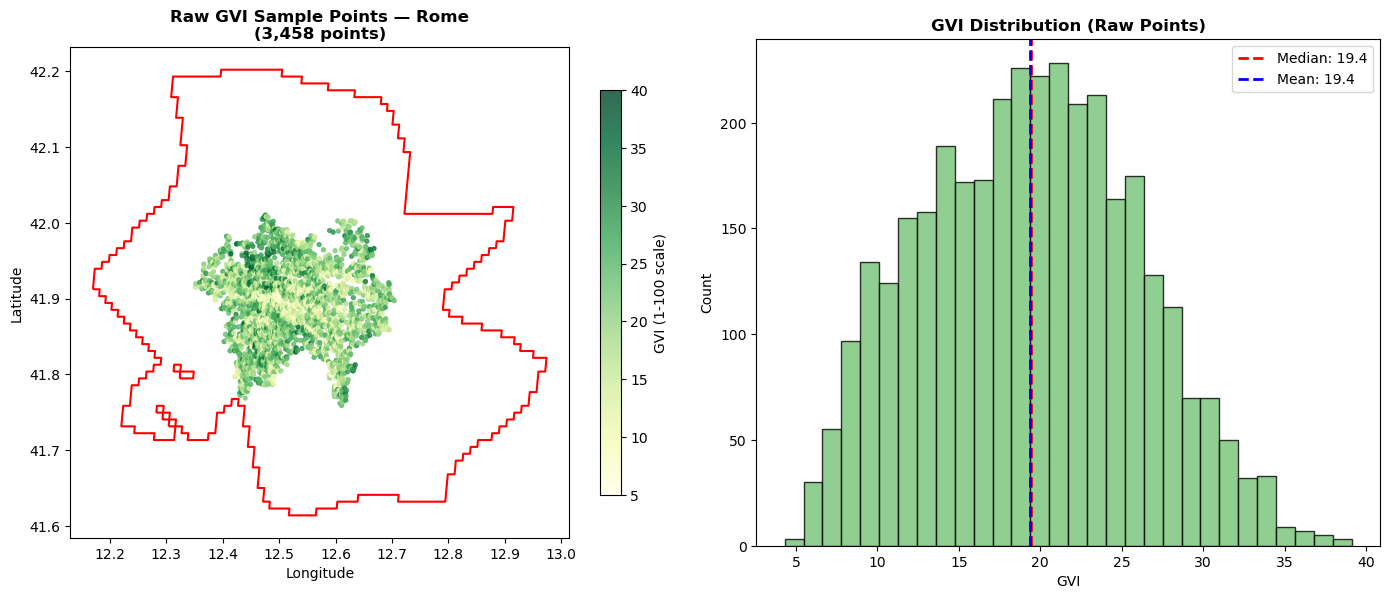

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_gvi_raw_points.png


In [12]:
import matplotlib.pyplot as plt

# Visualize raw GVI Points (before rasterization) 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load FUA for boundary
fua_4326 = gpd.read_file(fua_gpkg, layer="fua").to_crs("EPSG:4326")
gvi_4326 = gvi_gdf.to_crs("EPSG:4326")

# 1. Raw GVI points
ax1 = axes[0]
fua_4326.boundary.plot(ax=ax1, edgecolor="red", linewidth=1.5, label="FUA boundary")
scatter = ax1.scatter(gvi_4326.geometry.x, gvi_4326.geometry.y, 
                      c=gvi_4326["gvi"], cmap="YlGn", s=8, alpha=0.8,
                      vmin=5, vmax=40)
ax1.set_title(f"Raw GVI Sample Points — {CITY}\n({len(gvi_4326):,} points)", fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax1, label="GVI (1-100 scale)", shrink=0.8)

# 2. GVI histogram
ax2 = axes[1]
ax2.hist(gvi_gdf["gvi"], bins=30, color='#74c476', edgecolor='black', alpha=0.8)
ax2.axvline(gvi_gdf["gvi"].median(), color='red', linestyle='--', linewidth=2, 
            label=f'Median: {gvi_gdf["gvi"].median():.1f}')
ax2.axvline(gvi_gdf["gvi"].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {gvi_gdf["gvi"].mean():.1f}')
ax2.set_xlabel("GVI")
ax2.set_ylabel("Count")
ax2.set_title("GVI Distribution (Raw Points)", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_gvi_raw_points.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT / f'{SLUG}_gvi_raw_points.png'}")

### 1.6 Municipio Boundaries

In [13]:
# Load municipi rasters + masks created in NB5
z = np.load(INT / f"muni_on_ref_{SLUG}.npz")
muni_on_ref = z["muni_on_ref"].astype("int32")
muni_cov = z["muni_cov"].astype(bool)
ANALYSIS_MASK_MUNI = z["analysis_mask_muni"].astype(bool)

# Canonical masks (use these consistently)
MASK_CITY   = CITY_MASK
MASK_MUNI   = muni_cov
MASK_POLICY = ANALYSIS_MASK_MUNI  # = CITY_MASK ∩ municipi footprint

# Load Municipio GeoDataFrame (for names and geometry)
muni = gpd.read_file(INT / f"municipi_{SLUG}.gpkg")
print(f"✓ Loaded {len(muni)} Municipi from {INT / f'municipi_{SLUG}.gpkg'}")
print(f"  IDs: {sorted(muni['muni_id'].tolist())}")

# Assertions (catch drift early)
assert muni_on_ref.shape == MASK_CITY.shape == MASK_MUNI.shape == MASK_POLICY.shape
assert not np.any((muni_on_ref > 0) & (~MASK_MUNI)), "Leakage: labels outside muni_cov"
assert np.all(muni_on_ref[MASK_POLICY] > 0), "Unlabeled pixels inside analysis_mask_muni"
assert np.all(MASK_POLICY <= MASK_CITY), "MUNI domain must be subset of CITY_MASK"
assert np.all(MASK_POLICY <= MASK_MUNI), "MUNI domain must be subset of muni_cov"

print("✓ Loaded municipi masks:",
      "analysis pixels:", int(MASK_POLICY.sum()),
      "| remainder (CITY_MASK outside municipi):", int((MASK_CITY & ~MASK_MUNI).sum()),
      "| unique IDs (sample):", sorted(np.unique(muni_on_ref[MASK_POLICY]))[:5], "...")

# Policy scope used in this notebook (built-up within municipi policy domain)
SCOPE_PHYS = MASK_POLICY & BUILT_MASK

✓ Loaded 15 Municipi from /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/municipi_rome.gpkg
  IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
✓ Loaded municipi masks: analysis pixels: 70694 | remainder (CITY_MASK outside municipi): 7235 | unique IDs (sample): [1, 2, 3, 4, 5] ...


### 1.7 Physical Scope and GVI Rasterization

In [14]:
# Physical scope: built LCZ within city mask 
SCOPE_PHYS = MASK_POLICY & BUILT_MASK  # built-up within municipi policy domain

def compute_muni_gvi_stats(gvi_grid, muni_grid, scope_mask, muni_df, pop_grid=None):
    """
    Compute GVI statistics per Municipio.
    
    Returns DataFrame with:
    - muni_id, muni_name
    - gvi_mean: spatial mean GVI (built LCZ only)
    - gvi_popw: population-weighted mean GVI
    - n_pixels: number of valid pixels
    - population: total population in Municipio
    """
    records = []
    
    for _, row in muni_df.iterrows():
        mid = int(row["muni_id"])
        mname = row["muni_name"]
        
        # Mask for this Municipio
        m = (muni_grid == mid) & scope_mask & np.isfinite(gvi_grid)
        
        if m.sum() == 0:
            continue
        
        gvi_vals = gvi_grid[m]
        gvi_mean = float(np.mean(gvi_vals))
        n_pixels = int(m.sum())
        
        # Population-weighted mean
        if pop_grid is not None:
            pop_m = np.where(m, np.nan_to_num(pop_grid, nan=0.0), 0.0)
            total_pop = float(np.sum(pop_m))
            if total_pop > 0:
                gvi_popw = float(np.sum(gvi_vals * pop_m[m]) / total_pop)
            else:
                gvi_popw = gvi_mean
        else:
            total_pop = np.nan
            gvi_popw = gvi_mean
        
        records.append({
            "muni_id": mid,
            "muni_name": mname,
            "gvi_mean": gvi_mean,
            "gvi_popw": gvi_popw,
            "n_pixels": n_pixels,
            "population": total_pop
        })
    
    return pd.DataFrame(records).sort_values("muni_id").reset_index(drop=True)

muni_gvi = compute_muni_gvi_stats(gvi_on_ref, muni_on_ref, SCOPE_PHYS, muni, pop_on_ref)

print("\n=== Baseline GVI by Municipio ===")
print(muni_gvi.to_string(index=False))

print(f"\nCitywide GVI summary (spatial means across Municipi):")
print(f"  Min:    {muni_gvi['gvi_mean'].min():.2f}")
print(f"  Q1:     {muni_gvi['gvi_mean'].quantile(0.25):.2f}")
print(f"  Median: {muni_gvi['gvi_mean'].median():.2f}")
print(f"  Q3:     {muni_gvi['gvi_mean'].quantile(0.75):.2f}")
print(f"  Max:    {muni_gvi['gvi_mean'].max():.2f}")


=== Baseline GVI by Municipio ===
 muni_id           muni_name  gvi_mean  gvi_popw  n_pixels    population
       1    Municipio Roma I 16.389982 15.132407      1700 169068.578125
       2   Municipio Roma II 19.833924 18.793288      1732 165450.421875
       3  Municipio Roma III 20.958814 20.935588      2783 144651.843750
       4   Municipio Roma IV 18.182835 17.886077      3375 173737.531250
       5    Municipio Roma V 16.397141 15.946564      2585 177127.281250
       6   Municipio Roma VI 18.434601 17.882815      2223 125796.171875
       7  Municipio Roma VII 19.070501 17.323970      3897 261672.250000
       8 Municipio Roma VIII 21.181942 19.315671      2116 112030.320312
       9   Municipio Roma IX 20.960515 20.779337      6485 212798.546875
      10    Municipio Roma X 20.777520 20.520338      4008 220952.812500
      11   Municipio Roma XI 23.968745 20.460046      3698 112160.445312
      12  Municipio Roma XII 21.437093 19.783915      3127 137778.812500
      13 Municip

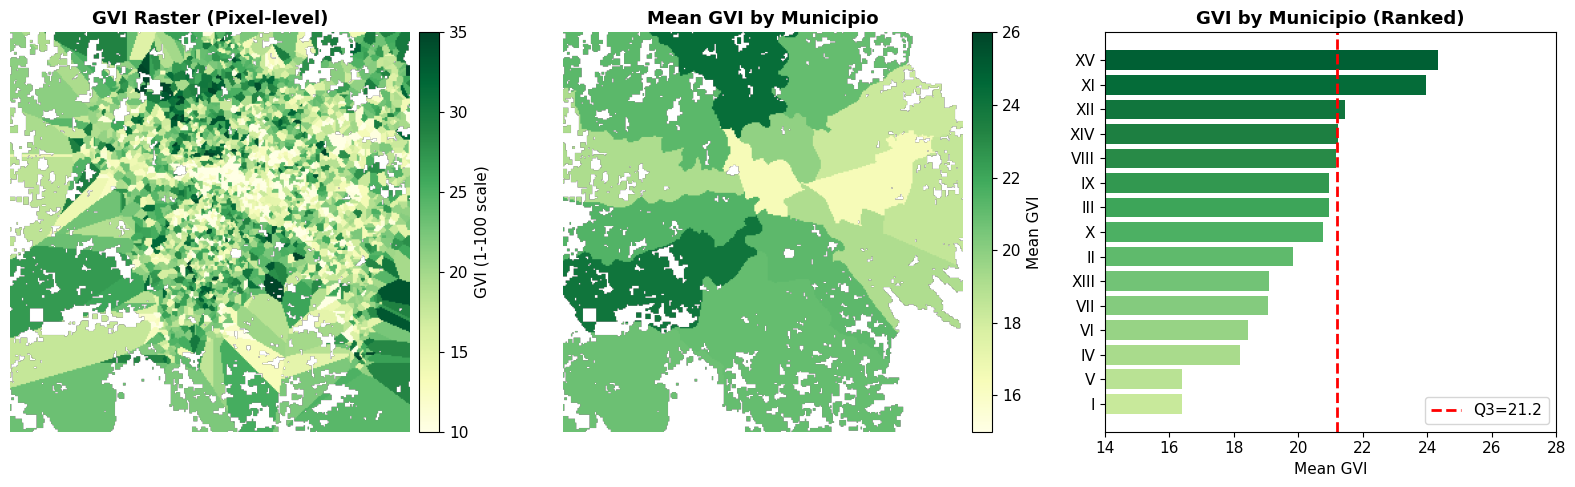

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_gvi_baseline.png


In [59]:
# Visualize GVI Baseline by Municipio 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
})

# Compute Q3 for reference line (will be formalized as TARGET_GVI later)
q3_gvi = float(muni_gvi['gvi_mean'].quantile(0.75))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. GVI Raster (continuous)
ax1 = axes[0]
gvi_plot = np.where(MASK_CITY, gvi_on_ref, np.nan)
im1 = ax1.imshow(gvi_plot, cmap='YlGn', vmin=10, vmax=35)
ax1.set_title('GVI Raster (Pixel-level)', fontweight='bold')
ax1.axis('off')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label='GVI (1-100 scale)')

# 2. GVI by Municipio (mean)
ax2 = axes[1]
gvi_by_muni = np.full_like(gvi_on_ref, np.nan)
for _, row in muni_gvi.iterrows():
    mid = int(row["muni_id"])
    gvi_by_muni[muni_on_ref == mid] = row["gvi_mean"]
gvi_by_muni = np.where(MASK_POLICY, gvi_by_muni, np.nan)
im2 = ax2.imshow(gvi_by_muni, cmap='YlGn', vmin=15, vmax=26)
ax2.set_title('Mean GVI by Municipio', fontweight='bold')
ax2.axis('off')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax2, label='Mean GVI')

# 3. Bar chart of GVI by Municipio
ax3 = axes[2]
muni_sorted = muni_gvi.sort_values('gvi_mean')
colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(muni_sorted)))
bars = ax3.barh(range(len(muni_sorted)), muni_sorted['gvi_mean'], color=colors)
ax3.set_yticks(range(len(muni_sorted)))
ax3.set_yticklabels([n.replace('Municipio Roma ', '') for n in muni_sorted['muni_name']])
ax3.axvline(q3_gvi, color='red', linestyle='--', linewidth=2, label=f'Q3={q3_gvi:.1f}')
ax3.set_xlabel('Mean GVI')
ax3.set_title('GVI by Municipio (Ranked)', fontweight='bold')
ax3.legend(loc='lower right')
ax3.set_xlim(14, 28)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_gvi_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT / f'{SLUG}_gvi_baseline.png'}")

# SECTION 2: POLICY DESIGN

The vegetation policy targets increasing urban green cover (GVI) to reduce
urban heat island effects and heat-related mortality.

### 2.1 Policy Framework

**Target**: Bring low-GVI areas up to the 75th percentile (Q3) of current distribution.

**Scope**: Built-up areas within the city (SCOPE_PHYS mask).

In [60]:
# Policy parameters 
# Target: Q3 of baseline GVI distribution (rounded up to 0.1)
Q3_RAW = float(muni_gvi["gvi_mean"].quantile(0.75))
TARGET_GVI = float(np.ceil(Q3_RAW * 10) / 10)  # Round up to nearest 0.1

# Optional cap on ΔGVI per Municipio (from config)
trees_cfg = cfg.get("trees", {}) or {}
CAP_DGVI = float(trees_cfg.get("cap_pp", 100.0))  # Default: no cap

print(f"\n=== Uniform Policy Parameters ===")
print(f"Q3 (raw):     {Q3_RAW:.2f}")
print(f"Target GVI:   {TARGET_GVI:.2f}")
print(f"ΔGVI cap:     {CAP_DGVI:.2f}")

# Compute ΔGVI per Municipio 
def compute_policy_dgvi(muni_gvi_df, target, cap=None):
    """
    Compute ΔGVI for each Municipio to reach target.
    ΔGVI = max(0, min(target - baseline, cap))
    """
    df = muni_gvi_df.copy()
    
    # Raw shortfall
    df["shortfall"] = target - df["gvi_mean"]
    
    # ΔGVI: positive shortfall, capped
    df["dGVI"] = df["shortfall"].clip(lower=0.0)
    if cap is not None and cap < 100:
        df["dGVI"] = df["dGVI"].clip(upper=cap)
    
    # Post-policy GVI
    df["gvi_after"] = df["gvi_mean"] + df["dGVI"]
    
    # Hit target?
    df["hit_target"] = df["gvi_after"] >= target - 0.001
    
    return df

policy_df = compute_policy_dgvi(muni_gvi, TARGET_GVI, CAP_DGVI)

print("\n=== Policy Result by Municipio ===")
cols = ["muni_id", "muni_name", "gvi_mean", "dGVI", "gvi_after", "hit_target"]
print(policy_df[cols].to_string(index=False))

# Summary statistics 
total_dGVI = float(policy_df["dGVI"].sum())
mean_dGVI = float(policy_df["dGVI"].mean())
n_treated = int((policy_df["dGVI"] > 0).sum())

print(f"\n=== Policy Summary ===")
print(f"Municipi treated:  {n_treated} / {len(policy_df)}")
print(f"Total ΔGVI:        {total_dGVI:.2f} points")
print(f"Mean ΔGVI:         {mean_dGVI:.2f} points")
print(f"Estimated cost:    €{total_dGVI * 10:.1f}M")


=== Uniform Policy Parameters ===
Q3 (raw):     21.20
Target GVI:   21.30
ΔGVI cap:     100.00

=== Policy Result by Municipio ===
 muni_id           muni_name  gvi_mean     dGVI  gvi_after  hit_target
       1    Municipio Roma I 16.389982 4.910018  21.300000        True
       2   Municipio Roma II 19.833924 1.466076  21.300000        True
       3  Municipio Roma III 20.958814 0.341186  21.300000        True
       4   Municipio Roma IV 18.182835 3.117165  21.300000        True
       5    Municipio Roma V 16.397141 4.902859  21.300000        True
       6   Municipio Roma VI 18.434601 2.865399  21.300000        True
       7  Municipio Roma VII 19.070501 2.229499  21.300000        True
       8 Municipio Roma VIII 21.181942 0.118058  21.300000        True
       9   Municipio Roma IX 20.960515 0.339485  21.300000        True
      10    Municipio Roma X 20.777520 0.522480  21.300000        True
      11   Municipio Roma XI 23.968745 0.000000  23.968745        True
      12  Munici

### 2.2 Uniform Policy (Bring Everyone Up)

Each Municipio below TARGET_GVI receives additional trees to reach the target.
ΔGVI = max(0, TARGET_GVI - baseline_GVI)

In [61]:
# Build ΔGVI map on reference grid 
# Each pixel gets the ΔGVI of its Municipio (uniform within Municipio)
# Create lookup table: muni_id -> dGVI

policy_df = muni_gvi.copy()
policy_df["dGVI"] = np.clip(TARGET_GVI - policy_df["gvi_mean"], 0, None)
policy_df["gvi_after"] = policy_df["gvi_mean"] + policy_df["dGVI"]

# Build ΔGVI map
dGVI_lut = dict(zip(policy_df["muni_id"], policy_df["dGVI"]))
dGVI_map = np.zeros((HGT, WDT), dtype=float)
for mid, dgvi in dGVI_lut.items():
    dGVI_map[muni_on_ref == mid] = dgvi

# Mask to physical scope
dGVI_map = np.where(SCOPE_PHYS, dGVI_map, 0)

print("ΔGVI map created.")
print(f"  Treated pixels: {(dGVI_map > 0).sum():,}")
print(f"  Max ΔGVI:       {dGVI_map.max():.2f}")

ΔGVI map created.
  Treated pixels: 38,643
  Max ΔGVI:       4.91


### 2.3 Policy Allocation Summary

In [62]:
# Compute total ΔGVI (sum over all Municipio)
total_dGVI_raw = float(policy_df["dGVI"].sum())
citywide_dGVI_popw = float(np.average(dGVI_map[SCOPE_PHYS], weights=pop_on_ref[SCOPE_PHYS]))

print("=== Uniform Policy Summary ===")
print(f"Total ΔGVI (sum of Municipio):  {total_dGVI_raw:.2f} index points")
print(f"Citywide ΔGVI (pop-weighted):   {citywide_dGVI_popw:.4f} points")
print(f"\nMunicipality allocation:")
for _, row in policy_df.sort_values("dGVI", ascending=False).head(5).iterrows():
    print(f"  {row['muni_name']}: GVI {row['gvi_mean']:.1f} → {row['gvi_after']:.1f} (Δ={row['dGVI']:.2f})")

=== Uniform Policy Summary ===
Total ΔGVI (sum of Municipio):  23.10 index points
Citywide ΔGVI (pop-weighted):   1.6503 points

Municipality allocation:
  Municipio Roma I: GVI 16.4 → 21.3 (Δ=4.91)
  Municipio Roma V: GVI 16.4 → 21.3 (Δ=4.90)
  Municipio Roma IV: GVI 18.2 → 21.3 (Δ=3.12)
  Municipio Roma VI: GVI 18.4 → 21.3 (Δ=2.87)
  Municipio Roma VII: GVI 19.1 → 21.3 (Δ=2.23)


### 2.4 Visualize Uniform Policy

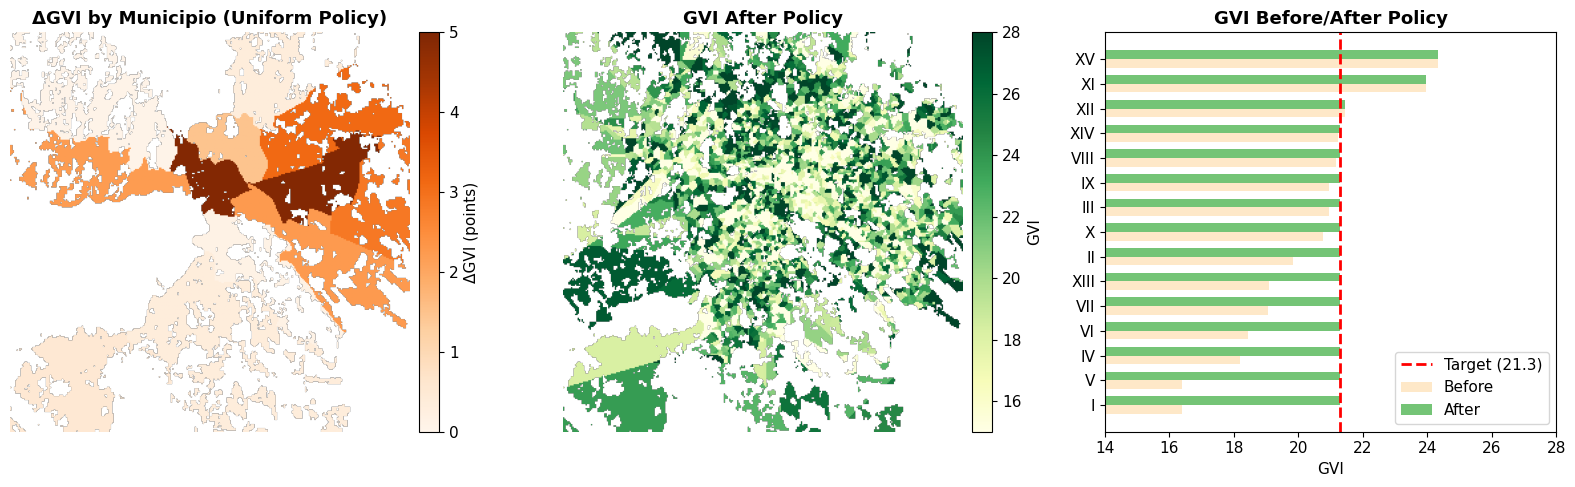

In [63]:
# Visualize Uniform Policy: ΔGVI Allocation 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ΔGVI Map
ax1 = axes[0]
dgvi_plot = np.where(SCOPE_PHYS & (dGVI_map > 0), dGVI_map, np.nan)
im1 = ax1.imshow(dgvi_plot, cmap='Oranges', vmin=0, vmax=5)
ax1.set_title('ΔGVI by Municipio (Uniform Policy)', fontweight='bold')
ax1.axis('off')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label='ΔGVI (points)')

# 2. Post-policy GVI
ax2 = axes[1]
gvi_after_map = np.where(SCOPE_PHYS, gvi_on_ref + dGVI_map, np.nan)
im2 = ax2.imshow(gvi_after_map, cmap='YlGn', vmin=15, vmax=28)
ax2.set_title('GVI After Policy', fontweight='bold')
ax2.axis('off')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax2, label='GVI')

# 3. Before/After bar chart
ax3 = axes[2]
policy_sorted = policy_df.sort_values('gvi_mean')
x = np.arange(len(policy_sorted))
width = 0.35

bars1 = ax3.barh(x - width/2, policy_sorted['gvi_mean'], width, label='Before', color='#fee8c8')
bars2 = ax3.barh(x + width/2, policy_sorted['gvi_after'], width, label='After', color='#74c476')

ax3.axvline(TARGET_GVI, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_GVI:.1f})')
ax3.set_yticks(x)
ax3.set_yticklabels([n.replace('Municipio Roma ', '') for n in policy_sorted['muni_name']])
ax3.set_xlabel('GVI')
ax3.set_title('GVI Before/After Policy', fontweight='bold')
ax3.legend(loc='lower right')
ax3.set_xlim(14, 28)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_uniform_policy_gvi.png", dpi=150, bbox_inches='tight')
plt.show()

# SECTION 3: BENEFITS CALCULATION

Tree planting reduces urban temperatures (UHI mitigation), which reduces
heat-related mortality. This section computes avoided deaths across scenarios.

### 3.1 Cooling Coefficients

Load GVI → ΔT relationship from literature/calibration data.

In [64]:
# Load cooling coefficients (GVI → T2M)
import unicodedata

def _norm(s):
    """Normalize string for matching."""
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode().lower()

# Load coefficient file
coef_path = P("CoolingEff") / "coefs_GVI_t2m.csv"
if coef_path.exists():
    coef_df = pd.read_csv(coef_path)
    print(f"Loading cooling coefficients from: {coef_path}")
    print(f"Columns: {coef_df.columns.tolist()}")
    
    # Match city
    city_tokens = [_norm(CITY), _norm(SLUG)]
    print(f"City tokens: {city_tokens}")
    
    if "city" in coef_df.columns:
        cities_in_file = coef_df["city"].unique()
        matched = [c for c in cities_in_file if _norm(c) in city_tokens or any(t in _norm(c) for t in city_tokens)]
        if matched:
            coef_city = coef_df[coef_df["city"].isin(matched)]
            print(f"Selected city: {matched}, rows: {len(coef_city)}")
        else:
            coef_city = coef_df
    else:
        coef_city = coef_df
else:
    print(f" Cooling coefficient file not found: {coef_path}")
    coef_city = None

Loading cooling coefficients from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/coefs_GVI_t2m.csv
Columns: ['Unnamed: 0', 'lcz', 'month', 'coef', 'city']
City tokens: ['rome', 'rome']
Selected city: ['Rome'], rows: 84


### 3.2 Build Monthly Cooling Profile

Compute monthly ΔT from GVI increase using the cooling coefficients.

In [65]:
# Summer months for averaging 
SUMMER_MONTHS = [5, 6, 7, 8, 9]  # May - September

def build_coef_lut(coef_df, mode="cooling_only"):
    """
    Build lookup table: (month, lcz) -> coefficient.
    """
    lut = {}
    
    for _, row in coef_df.iterrows():
        month = int(row["month"])
        lcz = int(row["lcz"]) if pd.notna(row["lcz"]) else None  # Changed from "lcz_code" to "lcz"
        coef = float(row["coef"])
        
        if lcz is None:
            continue
        
        if mode == "cooling_only":
            coef = min(coef, 0.0)
        
        lut[(month, lcz)] = coef
    
    return lut

def compute_monthly_dT(dGVI_grid, lcz_grid, scope_mask, coef_lut, months=range(1, 13)):
    """
    Compute monthly ΔT from vegetation policy.
    
    ΔT_pixel_month = ΔGVI_pixel × coef(LCZ_pixel, month)
    
    Returns: (n_months, H, W) array
    """
    h, w = dGVI_grid.shape
    max_lcz = int(np.nanmax(lcz_grid))
    
    dT_stack = []
    
    for m in months:
        # Build LCZ -> coef array for this month
        lcz_to_coef = np.zeros(max_lcz + 1, dtype=float)
        for lcz in range(1, max_lcz + 1):
            lcz_to_coef[lcz] = coef_lut.get((m, lcz), 0.0)
        
        # Get coef for each pixel
        coef_grid = lcz_to_coef[np.clip(lcz_grid, 0, max_lcz)]
        
        # ΔT = ΔGVI × coef
        dT = np.where(scope_mask, dGVI_grid * coef_grid, 0.0).astype("float32")
        dT_stack.append(dT)
    
    return np.stack(dT_stack, axis=0)

def compute_popw_mean(grid, pop_grid, mask):
    """Population-weighted mean within mask."""
    valid = mask & np.isfinite(grid) & (pop_grid > 0)
    if valid.sum() == 0:
        return np.nan
    return float(np.average(grid[valid], weights=pop_grid[valid]))

# Build coefficient LUT (cooling only - conservative)
coef_lut = build_coef_lut(coef_city, mode="cooling_only")

# Compute monthly ΔT
dT_monthly = compute_monthly_dT(dGVI_map, lcz_on_ref, SCOPE_PHYS, coef_lut)
print(f"Monthly ΔT computed: shape {dT_monthly.shape}")

# Summer mean ΔT
summer_indices = [m - 1 for m in SUMMER_MONTHS]
dT_summer = dT_monthly[summer_indices].mean(axis=0)

print(f"\nSummer ΔT (May-Sep average):")
print(f"  Min:  {dT_summer.min():.4f} °C")
print(f"  Mean: {dT_summer[SCOPE_PHYS].mean():.4f} °C")
print(f"  Max:  {dT_summer.max():.4f} °C")

# Population-weighted summer cooling
dT_summer_popw = compute_popw_mean(dT_summer, pop_on_ref, SCOPE_PHYS)
print(f"  Pop-weighted: {dT_summer_popw:.4f} °C")

Monthly ΔT computed: shape (12, 301, 301)

Summer ΔT (May-Sep average):
  Min:  -0.2837 °C
  Mean: -0.0070 °C
  Max:  0.0000 °C
  Pop-weighted: -0.0072 °C


### 3.3 Visualize Cooling Effect

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cooling_effect.png


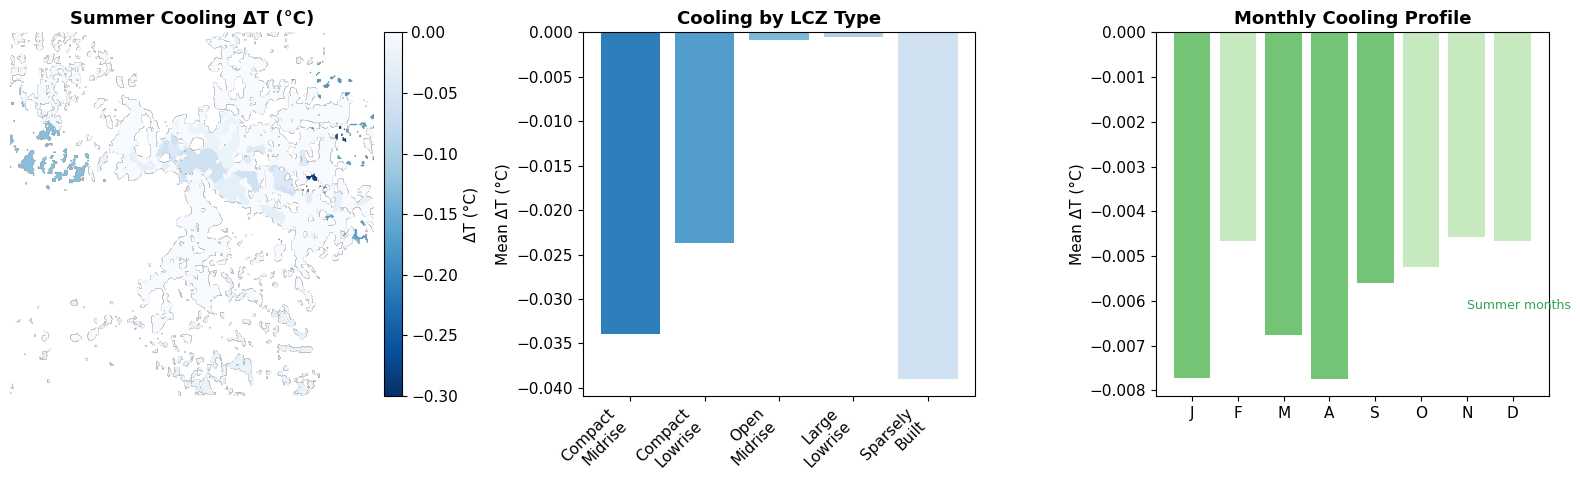

In [66]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

# Get available LCZ codes from coefficient data
available_lcz = sorted(coef_city["lcz"].dropna().unique().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Summer ΔT Map
ax1 = axes[0]
dt_plot = np.where(SCOPE_PHYS & (dT_summer < 0), dT_summer, np.nan)
im1 = ax1.imshow(dt_plot, cmap='Blues_r', vmin=-0.3, vmax=0)
ax1.set_title('Summer Cooling ΔT (°C)', fontweight='bold')
ax1.axis('off')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label='ΔT (°C)')

# 2. ΔT by LCZ type
ax2 = axes[1]
lcz_names = {2: 'Compact\nMidrise', 3: 'Compact\nLowrise', 4: 'Open\nHighrise',
             5: 'Open\nMidrise', 6: 'Open\nLowrise', 8: 'Large\nLowrise', 9: 'Sparsely\nBuilt'}
lcz_dt = []
lcz_labels = []
for lcz_code in sorted(available_lcz):
    mask = (lcz_on_ref == lcz_code) & SCOPE_PHYS & (dT_summer < 0)
    if mask.sum() > 0:
        mean_dt = dT_summer[mask].mean()
        lcz_dt.append(mean_dt)
        lcz_labels.append(lcz_names.get(lcz_code, f'LCZ {lcz_code}'))

colors = plt.cm.Blues_r(np.linspace(0.3, 0.8, len(lcz_dt)))
ax2.bar(range(len(lcz_dt)), lcz_dt, color=colors)
ax2.set_xticks(range(len(lcz_dt)))
ax2.set_xticklabels(lcz_labels, rotation=45, ha='right')
ax2.set_ylabel('Mean ΔT (°C)')
ax2.set_title('Cooling by LCZ Type', fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.5)

# 3. Monthly cooling profile
ax3 = axes[2]
monthly_dt_city = [float(dT_monthly[m-1][SCOPE_PHYS].mean()) for m in range(1, 13)]
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
colors_monthly = ['#74c476' if m in SUMMER_MONTHS else '#c7e9c0' for m in range(1, 13)]
ax3.bar(months, monthly_dt_city, color=colors_monthly)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_ylabel('Mean ΔT (°C)')
ax3.set_title('Monthly Cooling Profile', fontweight='bold')
ax3.annotate('Summer months', xy=(6, min(monthly_dt_city)*0.8), fontsize=9, color='#31a354')

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_cooling_effect.png", dpi=150, bbox_inches='tight')
print(f"Saved: {OUT / f'{SLUG}_cooling_effect.png'}")
plt.show()

### 3.4 Load Hazard and AC Coverage

Load daily T2M hazard and AC coverage maps for mortality calculation.

In [67]:
# Load daily T2M hazard 
from climada.hazard import Hazard

haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)

# Restore daily metadata
events_csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
if events_csv.exists():
    ev_df = pd.read_csv(events_csv)
    H.event_id = ev_df["event_id"].to_numpy(int)
    H.date = pd.to_datetime(ev_df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d}" for d in ev_df["date"]], dtype=object)
    
    def days_in_year(y):
        return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365
    yrs = pd.to_datetime(ev_df["date"]).dt.year.to_numpy(int)
    H.frequency = np.array([1.0 / days_in_year(y) for y in yrs], dtype=float)

H.haz_type = "T2M"
H.units = "degC (daily mean)"

dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = sorted(dates_h.dt.year.unique().astype(int).tolist())
print(f"Hazard loaded: {H.intensity.shape[0]} events, years {YEARS_H}")

# Load AC coverage and efficacy from NB5 
ac_maps_path = INT / f"ac_coverage_maps_{SLUG}.npz"
if not ac_maps_path.exists():
    ac_maps_path = INT / "ac_coverage_maps.npz"

if not ac_maps_path.exists():
    raise FileNotFoundError(f"AC coverage maps not found: {ac_maps_path}")

npz = np.load(ac_maps_path)
print(f"Loaded: {ac_maps_path.name}")
print(f"Keys: {npz.files}")

# Efficacy from NB5 (keeps whatever scenario was used there) 
EFF_DEFAULT = float(npz["EFF_DEFAULT"][0]) if "EFF_DEFAULT" in npz.files else 0.30
EFF_MAP = {"default": EFF_DEFAULT}
if "EFF_BUCKETS_LT15" in npz.files:
    EFF_MAP["<15"] = float(npz["EFF_BUCKETS_LT15"][0])
if "EFF_BUCKETS_15_64" in npz.files:
    EFF_MAP["15-64"] = float(npz["EFF_BUCKETS_15_64"][0])
if "EFF_BUCKETS_65P" in npz.files:
    EFF_MAP["65+"] = float(npz["EFF_BUCKETS_65P"][0])
print(f"EFF_MAP (from NB5): {EFF_MAP}")

def get_eff_for_age(age_label):
    """Get AC efficacy for age group (uses NB5's saved scenario)."""
    if age_label in EFF_MAP:
        return float(EFF_MAP[age_label])
    for k, v in EFF_MAP.items():
        if k == "default":
            continue
        if k in str(age_label):
            return float(v)
    return float(EFF_DEFAULT)

# Coverage arrays (3D or 2D) 
cov_base_raw = npz["coverage_base_3d"] if "coverage_base_3d" in npz.files else npz.get("coverage_base")
cov_policy_raw = npz["coverage_policy_3d"] if "coverage_policy_3d" in npz.files else npz.get("coverage_policy")

# Years for the cubes
if "YEARS_AC" in npz.files:
    YEARS_AC = npz["YEARS_AC"].astype(int).tolist()
elif "years" in npz.files:
    YEARS_AC = npz["years"].astype(int).tolist()
else:
    YEARS_AC = YEARS_H

def _build_cov_by_year(arr, years_in_file):
    """Convert 2D or 3D array to {year: 2D grid} dict."""
    if arr is None:
        return {int(y): np.zeros((HGT, WDT), dtype="float32") for y in YEARS_H}
    if arr.ndim == 2:
        # Same 2D map for all hazard years
        return {int(y): np.nan_to_num(arr.astype("float32"), nan=0.0) for y in YEARS_H}
    if arr.ndim == 3:
        assert years_in_file is not None, "3D coverage cube but missing YEARS_AC in NPZ"
        assert arr.shape[0] == len(years_in_file), f"cube length {arr.shape[0]} != YEARS_AC length {len(years_in_file)}"
        return {int(y): np.nan_to_num(arr[i].astype("float32"), nan=0.0)
                for i, y in enumerate(years_in_file)}
    raise ValueError(f"Unexpected coverage array dim {arr.ndim}")

coverage_base_by_year = _build_cov_by_year(cov_base_raw, YEARS_AC)
coverage_policy_by_year = _build_cov_by_year(cov_policy_raw, YEARS_AC)

print(f"Coverage base years: {sorted(coverage_base_by_year.keys())}")
print(f"Coverage policy years: {sorted(coverage_policy_by_year.keys())}")
print(f"Base grid shape: {next(iter(coverage_base_by_year.values())).shape}")

Hazard loaded: 1462 events, years [2020, 2030, 2040, 2050]
Loaded: ac_coverage_maps_rome.npz
Keys: ['coverage_base_3d', 'coverage_policy_3d', 'YEARS_AC', 'years', 'coverage_base', 'coverage_policy', 'ANCHOR_YEAR', 'CITY_MASK', 'CAP_PIX', 'CAP_MASK_ANCHOR', 'HGT', 'WDT', 'EFF_SCENARIO', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P']
EFF_MAP (from NB5): {'default': 0.30000001192092896, '<15': 0.20000000298023224, '15-64': 0.30000001192092896, '65+': 0.4000000059604645}
Coverage base years: [2020, 2030, 2040, 2050]
Coverage policy years: [2020, 2030, 2040, 2050]
Base grid shape: (301, 301)


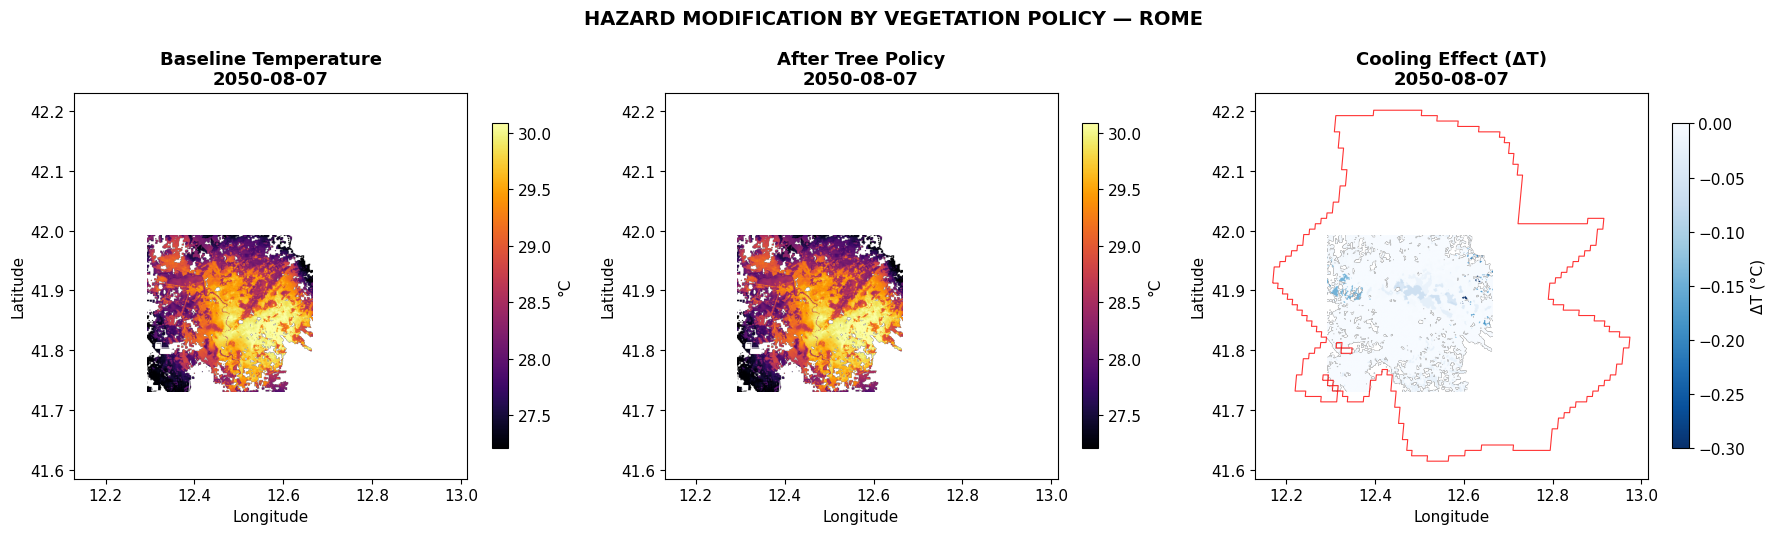


Focus date: 2050-08-07 (hottest summer day in 2050)
Baseline mean T: 28.761°C
After-trees mean T: 28.755°C
Mean cooling: -0.0053°C
Max cooling: -0.3167°C

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_hazard_before_after.png


In [68]:
# Visualize Hazard Before and After Trees 

def _row_to_grid(intensity, i_ev, grid_shape):
    """Extract intensity for one event and reshape to grid."""
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()
    expected = grid_shape[0] * grid_shape[1]
    if row.size == expected:
        return row.reshape(grid_shape)
    if row.size == 1:
        return np.full(grid_shape, row[0], dtype=float)
    raise ValueError(f"Row size {row.size} != grid cells {expected} and != 1")

# Pick a hot summer day from the hazard
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
FOCUS_YEAR = 2050
# Find hottest day in focus year (July-August)
year_mask = dates.dt.year == FOCUS_YEAR
summer_mask = dates.dt.month.isin([7, 8])
combined_mask = year_mask & summer_mask
summer_indices_h = np.where(combined_mask)[0]

if len(summer_indices_h) > 0:
    # Get mean temperature for each summer day
    summer_temps = []
    for idx in summer_indices_h:
        I_grid = _row_to_grid(H.intensity, idx, MASK_POLICY.shape)
        summer_temps.append(np.nanmean(I_grid[MASK_POLICY]))
    
    # Pick the hottest day
    hottest_idx = summer_indices_h[np.argmax(summer_temps)]
    focus_date = pd.Timestamp(dates.iloc[hottest_idx]).strftime('%Y-%m-%d')
    
    # Extract hazard for this day
    I_base = _row_to_grid(H.intensity, hottest_idx, MASK_POLICY.shape)
    I_base_m = np.where(MASK_POLICY, I_base, np.nan)
    
    # Apply tree cooling
    focus_month = pd.Timestamp(dates.iloc[hottest_idx]).month
    I_tree = I_base + dT_monthly[focus_month - 1]  # 0-indexed
    I_tree_m = np.where(MASK_POLICY, I_tree, np.nan)
    
    # Difference
    dT_map = I_tree_m - I_base_m
    
    # Compute extent in lon/lat for nice axes
    # Get bounds from transform
    left = ref_transform.c
    top = ref_transform.f
    right = left + ref_transform.a * WDT
    bottom = top + ref_transform.e * HGT
    
    # Transform corners to WGS84
    from pyproj import Transformer
    transformer = Transformer.from_crs(ref_crs, "EPSG:4326", always_xy=True)
    lon_min, lat_min = transformer.transform(left, bottom)
    lon_max, lat_max = transformer.transform(right, top)
    extent = [lon_min, lon_max, lat_min, lat_max]
    
    # Load FUA boundary
    fua_ref = gpd.read_file(fua_gpkg, layer="fua").to_crs(ref_crs)
    fua_4326 = fua_ref.to_crs("EPSG:4326")
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    vmin, vmax = np.nanpercentile(I_base_m, [2, 98])
    
    # 1. Baseline hazard
    ax1 = axes[0]
    im1 = ax1.imshow(I_base_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
    fua_4326.boundary.plot(ax=ax1, color="white", linewidth=0.8, alpha=0.8)
    ax1.set_title(f"Baseline Temperature\n{focus_date}", fontweight='bold')
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")
    plt.colorbar(im1, ax=ax1, label="°C", shrink=0.8)
    
    # 2. After trees
    ax2 = axes[1]
    im2 = ax2.imshow(I_tree_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
    fua_4326.boundary.plot(ax=ax2, color="white", linewidth=0.8, alpha=0.8)
    ax2.set_title(f"After Tree Policy\n{focus_date}", fontweight='bold')
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    plt.colorbar(im2, ax=ax2, label="°C", shrink=0.8)
    
    # 3. Cooling effect (ΔT)
    ax3 = axes[2]
    im3 = ax3.imshow(dT_map, origin="upper", extent=extent, vmin=-0.3, vmax=0, cmap="Blues_r")
    fua_4326.boundary.plot(ax=ax3, color="red", linewidth=0.8, alpha=0.8)
    ax3.set_title(f"Cooling Effect (ΔT)\n{focus_date}", fontweight='bold')
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")
    plt.colorbar(im3, ax=ax3, label="ΔT (°C)", shrink=0.8)
    
    plt.suptitle(f"HAZARD MODIFICATION BY VEGETATION POLICY — {CITY.upper()}", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_hazard_before_after.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFocus date: {focus_date} (hottest summer day in {FOCUS_YEAR})")
    print(f"Baseline mean T: {np.nanmean(I_base_m):.3f}°C")   # 3 decimals
    print(f"After-trees mean T: {np.nanmean(I_tree_m):.3f}°C")
    print(f"Mean cooling: {np.nanmean(dT_map[MASK_POLICY]):.4f}°C")
    print(f"Max cooling: {np.nanmin(dT_map[MASK_POLICY]):.4f}°C")
    print(f"\nSaved: {OUT / f'{SLUG}_hazard_before_after.png'}")

else:
    print(f"[WARN] No summer days found for year {FOCUS_YEAR}")

### 3.5 Load Impact Functions

Load scaled MDD (mortality dose-response) curves from NB4.

In [69]:
# Load SCALED impact functions from NB4 (JSON format) 
import json
from pathlib import Path
from climada.entity.impact_funcs import ImpactFunc

def _mk_if(haz_type: str, v: dict) -> ImpactFunc:
    """Create ImpactFunc from dict with id, intensity, mdd, name."""
    f = ImpactFunc(
        haz_type=haz_type,
        id=int(v["id"]),
        intensity=np.asarray(v["intensity"], float),
        mdd=np.asarray(v["mdd"], float),  # Already SCALED in NB4 output
        paa=np.ones(len(v["intensity"]), float),
        name=v.get("name", "IF"),
    )
    f.check()
    return f

def load_scaled_ifs_by_year_nb4(interim_path, slug, haz_type="T2M"):
    """
    Load NB4's year-specific SCALED MDD bundle.
    Expected file: if_curves_by_year_{slug}.json
    """
    interim_path = Path(interim_path)
    path = interim_path / f"if_curves_by_year_{slug}.json"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path.name} in {interim_path}.\n"
            "Re-run NB4 and save the YEAR-SPECIFIC SCALED IF bundle."
        )
    
    with open(path, "r") as fh:
        obj = json.load(fh)
    
    raw = obj.get("ifs_by_year", {})
    if not raw:
        raise ValueError(f"{path.name} has no 'ifs_by_year'.")
    
    ifs_by_year = {}
    for y_key, d in raw.items():
        y = int(y_key)
        ifs_by_year[y] = {age: _mk_if(haz_type, v) for age, v in d.items()}
    
    meta = {
        "reference_year": obj.get("reference_year", None),
        "years": obj.get("years", sorted(ifs_by_year.keys())),
        "scaling_source": obj.get("scaling_source", None),
    }
    
    return ifs_by_year, path, meta

# Load IFs from NB4
IFS_BY_YEAR, IF_SRC, IF_META = load_scaled_ifs_by_year_nb4(INT, SLUG, haz_type="T2M")
print(f" Loaded SCALED IFs from: {IF_SRC.name}")
print(f"  Years: {sorted(IFS_BY_YEAR.keys())}")
print(f"  Age groups: {list(IFS_BY_YEAR[list(IFS_BY_YEAR.keys())[0]].keys())}")
print(f"  Meta: {IF_META}")

def get_age_ifs_for_year(year: int):
    """Get age-specific impact functions for a given year."""
    year = int(year)
    if year not in IFS_BY_YEAR:
        raise KeyError(f"No SCALED IFs for year {year}. Available: {sorted(IFS_BY_YEAR.keys())}")
    return IFS_BY_YEAR[year]

 Loaded SCALED IFs from: if_curves_by_year_rome.json
  Years: [2020, 2030, 2040, 2050]
  Age groups: ['<15', '15-64', '65+']
  Meta: {'reference_year': 2020, 'years': [2020, 2030, 2040, 2050], 'scaling_source': 'Wittgenstein ASSR baseline mortality'}


### 3.6 Mortality Model

Compute annual deaths with AC protection and tree cooling effects.

In [70]:
# Compute all death scenarios 

def _eff_for_age(age_lbl, eff_map=EFF_MAP, eff_default=EFF_DEFAULT):
    """Get AC efficacy for age group."""
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def _row_to_grid(intensity, i_ev, grid_shape):
    """Extract intensity for one event and reshape to grid."""
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()
    expected = grid_shape[0] * grid_shape[1]
    if row.size == expected:
        return row.reshape(grid_shape)
    if row.size == 1:
        return np.full(grid_shape, row[0], dtype=float)
    raise ValueError(f"Row size {row.size} != grid cells {expected} and != 1")

def annual_deaths_with_ac_and_dT(H, dT_monthly, coverage_by_year, age_by_year, pop_by_year, mask=None):
    """
    Annual heat deaths per age group, applying MONTHLY temperature offset and AC coverage.
    
    Parameters:
    -----------
    H : Hazard object
    dT_monthly : array (12, H, W) - monthly cooling grids (index 0 = January, etc.)
                 OR (H, W) for backward compatibility (same offset all months)
    """
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    years = np.sort(np.unique(dates.dt.year.astype(int)))

    age_labels = list(get_age_ifs_for_year(int(years[0])).keys())
    # Scope mask for totals (defaults to municipi policy mask if available)
    if mask is None:
        mask = globals().get('MASK_POLICY', globals().get('mask'))
    mask = mask.astype(bool)
    grid_shape = mask.shape
    totals = {a: pd.Series(0.0, index=years, dtype=float) for a in age_labels}

    # Check if dT_monthly is (12, H, W) or just (H, W)
    if dT_monthly.ndim == 3:
        use_monthly = True
    else:
        use_monthly = False
        dT_fixed = dT_monthly  # backward compatibility

    for i_ev, d in enumerate(dates):
        y = int(d.year)
        age_ifs_y = get_age_ifs_for_year(y)

        cov_y = coverage_by_year.get(y)
        if cov_y is None:
            raise KeyError(f"No AC coverage for year {y}")
        cov_y = np.nan_to_num(cov_y.astype(float), nan=0.0)

        I_grid = _row_to_grid(H.intensity, i_ev, grid_shape)
        
        # Get month-specific offset
        if use_monthly:
            month_idx = d.month - 1  # 0-indexed (Jan=0, Dec=11)
            dT_offset = dT_monthly[month_idx]
        else:
            dT_offset = dT_fixed
        
        I_policy = I_grid + dT_offset
        m_city = mask & np.isfinite(I_grid)

        for age_lbl in age_labels:
            f = age_ifs_y[age_lbl]
            mdd = np.interp(I_policy, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
            eff_a = _eff_for_age(age_lbl)
            mult = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)
            pop_a_grid = np.nan_to_num(age_by_year[y][age_lbl], 0.0)
            totals[age_lbl].loc[y] += float(np.nansum(np.where(m_city, pop_a_grid * mdd * mult, 0.0)))

    yr_totals = pd.DataFrame(totals).sort_index()
    yr_totals["overall"] = yr_totals[age_labels].sum(axis=1)

    # Per 100k rates
    age_pops = {int(y): {a: float(np.nansum(np.nan_to_num(age_by_year[int(y)][a], 0.0)[mask]))
                         for a in age_labels} for y in years}
    city_pop = {int(y): sum(age_pops[int(y)][a] for a in age_labels) for y in years}

    yr_rates = yr_totals.copy()
    for a in age_labels:
        denom = np.array([age_pops[int(y)][a] for y in years], dtype=float)
        yr_rates[a] = np.where(denom > 0, yr_totals[a].to_numpy(float) / denom * 1e5, np.nan)
    denom_all = np.array([city_pop[int(y)] for y in years], dtype=float)
    yr_rates["overall"] = np.where(denom_all > 0, yr_totals["overall"].to_numpy(float) / denom_all * 1e5, np.nan)

    return yr_rates, yr_totals

### 3.7 Compute Four Scenarios

1. **Baseline**: Current AC, no trees
2. **Trees only**: Current AC + tree cooling
3. **AC policy only**: AC policy, no trees
4. **Both policies**: AC policy + tree cooling

In [71]:
# Zero offset for non-tree scenarios
dT_zero = np.zeros((HGT, WDT), dtype="float32")
print("Computing 4 scenarios...")

# dT_summer: T reduced by tree cooling 
# 1. Baseline: current AC, no trees
print("  1/4: Baseline (current AC, no trees)...")
yr_rates_base, yr_totals_base = annual_deaths_with_ac_and_dT(
    H, dT_zero, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

# 2. Trees only: current AC + trees
print("  2/4: Trees only (current AC + trees)...")
yr_rates_trees, yr_totals_trees = annual_deaths_with_ac_and_dT(
    H, dT_monthly, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

# 3. AC policy only: AC policy, no trees
print("  3/4: AC policy only (no trees)...")
yr_rates_acpol, yr_totals_acpol = annual_deaths_with_ac_and_dT(
    H, dT_zero, coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

# 4. Both policies: AC policy + trees
print("  4/4: Both policies (AC policy + trees)...")
yr_rates_both, yr_totals_both = annual_deaths_with_ac_and_dT(
    H, dT_monthly, coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year
)

print("\n✓ All scenarios computed.")
print(f"\nBaseline deaths (current AC):\n{yr_totals_base.round(1)}")

print("\nDeaths with trees (current AC):")
print(yr_totals_trees.round(1))

print("\nDeaths with AC policy (no trees):")
print(yr_totals_acpol.round(1))

print("\nDeaths with both policies:")
print(yr_totals_both.round(1))

Computing 4 scenarios...
  1/4: Baseline (current AC, no trees)...
  2/4: Trees only (current AC + trees)...
  3/4: AC policy only (no trees)...
  4/4: Both policies (AC policy + trees)...

✓ All scenarios computed.

Baseline deaths (current AC):
      <15  15-64    65+  overall
2020  3.4   64.1  379.1    446.5
2030  1.9   56.8  469.5    528.3
2040  1.1   36.6  537.9    575.5
2050  0.6   20.9  547.0    568.5

Deaths with trees (current AC):
      <15  15-64    65+  overall
2020  3.4   63.9  377.8    445.1
2030  1.9   56.7  468.1    526.7
2040  1.1   36.5  536.2    573.8
2050  0.6   20.8  545.3    566.7

Deaths with AC policy (no trees):
      <15  15-64    65+  overall
2020  3.4   61.9  360.8    426.1
2030  1.9   55.0  447.9    504.8
2040  1.1   35.6  516.9    553.7
2050  0.6   20.3  525.8    546.7

Deaths with both policies:
      <15  15-64    65+  overall
2020  3.3   61.8  359.6    424.7
2030  1.9   54.9  446.5    503.2
2040  1.1   35.5  515.4    552.0
2050  0.6   20.3  524.2    545

### 3.8 Avoided Deaths Summary

In [72]:
# Avoided deaths summary 
print("\n" + "="*80)
print("AVOIDED DEATHS SUMMARY")
print("="*80)

# Avoided by trees only (vs current AC baseline)
avo_trees = yr_totals_base - yr_totals_trees
avo_trees.columns = [f"avo_{c}" for c in avo_trees.columns]

# Avoided by AC policy only (vs current AC baseline)
avo_ac = yr_totals_base - yr_totals_acpol
avo_ac.columns = [f"avo_{c}" for c in avo_ac.columns]

# Avoided by both policies (vs current AC baseline)
avo_both = yr_totals_base - yr_totals_both
avo_both.columns = [f"avo_{c}" for c in avo_both.columns]

# Incremental benefit of trees on top of AC policy
avo_trees_cond = yr_totals_acpol - yr_totals_both
avo_trees_cond.columns = [f"avo_{c}" for c in avo_trees_cond.columns]

print("\n--- Avoided by Trees Only (vs current AC baseline) ---")
print(avo_trees.round(2))

print("\n--- Avoided by AC Policy Only (vs current AC baseline) ---")
print(avo_ac.round(2))

print("\n--- Avoided by Both Policies (vs current AC baseline) ---")
print(avo_both.round(2))

print("\n--- Incremental Benefit of Trees (given AC policy) ---")
print(avo_trees_cond.round(2))

# Summary table
print("\n--- Summary: Overall Avoided Deaths ---")
summary = pd.DataFrame({
    "baseline": yr_totals_base["overall"],
    "trees_only": yr_totals_trees["overall"],
    "ac_policy_only": yr_totals_acpol["overall"],
    "both_policies": yr_totals_both["overall"],
    "avo_trees": avo_trees["avo_overall"],
    "avo_ac": avo_ac["avo_overall"],
    "avo_both": avo_both["avo_overall"],
    "avo_trees_cond": avo_trees_cond["avo_overall"],
})
print(summary.round(2))


AVOIDED DEATHS SUMMARY

--- Avoided by Trees Only (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.01       0.18     1.26         1.44
2030     0.00       0.15     1.46         1.61
2040     0.00       0.09     1.64         1.73
2050     0.00       0.05     1.70         1.76

--- Avoided by AC Policy Only (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.07       2.12    18.24        20.43
2030     0.04       1.80    21.66        23.49
2040     0.02       0.97    20.91        21.89
2050     0.01       0.55    21.24        21.80

--- Avoided by Both Policies (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.08       2.29    19.44        21.81
2030     0.04       1.94    23.05        25.04
2040     0.02       1.06    22.48        23.56
2050     0.01       0.60    22.88        23.49

--- Incremental Benefit of Trees (given AC policy) ---
      avo_<15  avo_15-64  avo_65+  avo_o

### 3.9 Visualize Deaths and Avoided Deaths

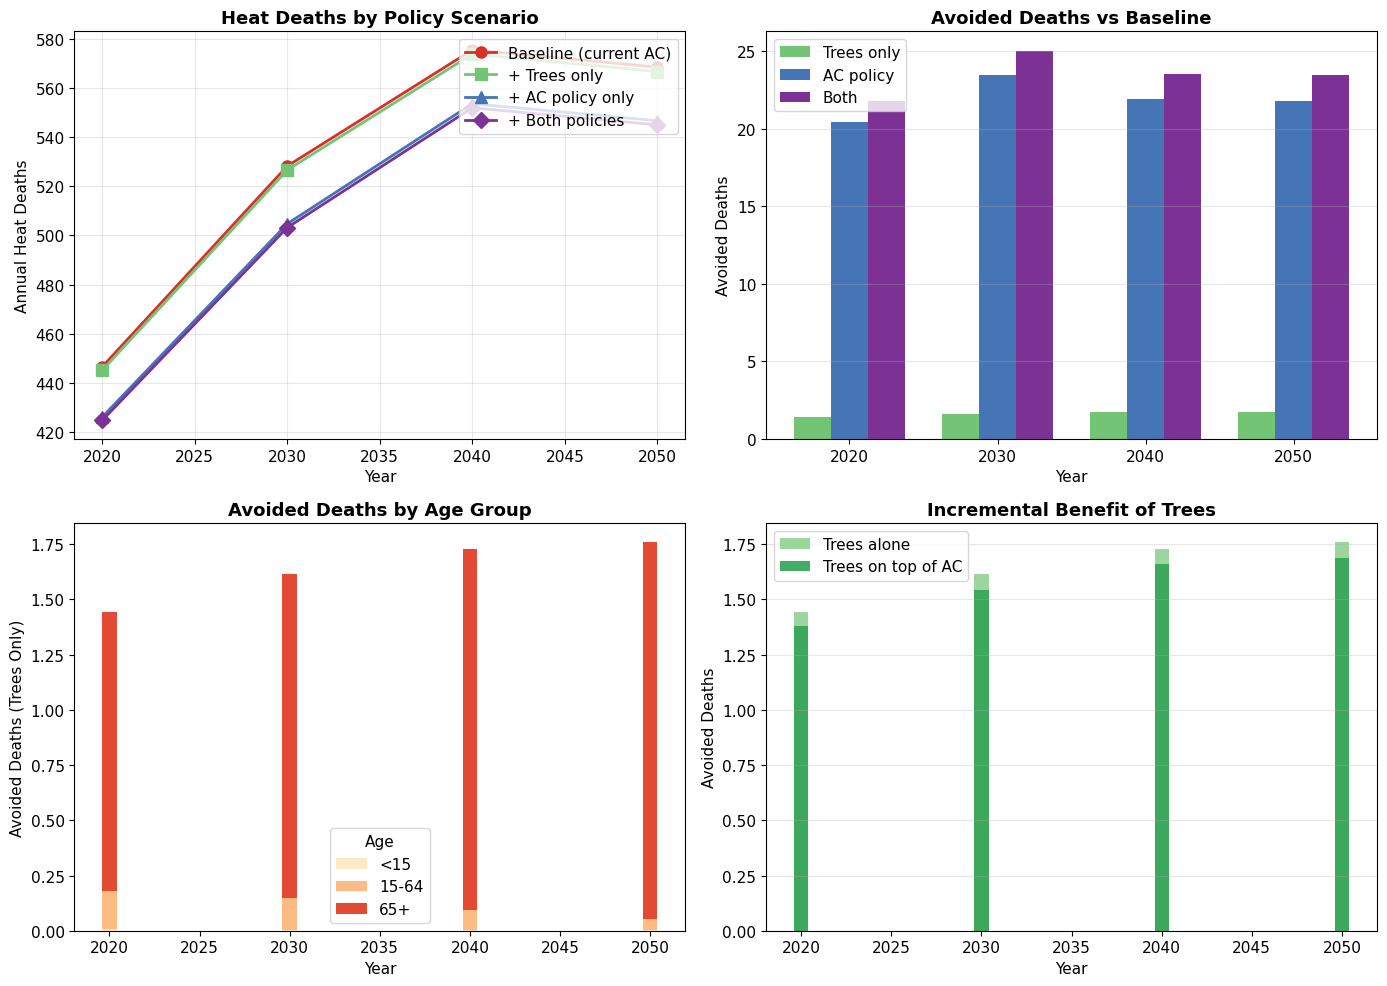

In [73]:
# Visualize Deaths and Avoided Deaths 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Deaths by scenario (time series)
ax1 = axes[0, 0]
years = yr_totals_base.index.tolist()
ax1.plot(years, yr_totals_base['overall'], 'o-', label='Baseline (current AC)', 
         color='#d73027', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_trees['overall'], 's-', label='+ Trees only', 
         color='#74c476', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_acpol['overall'], '^-', label='+ AC policy only', 
         color='#4575b4', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_both['overall'], 'D-', label='+ Both policies', 
         color='#7b3294', linewidth=2, markersize=8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Heat Deaths')
ax1.set_title('Heat Deaths by Policy Scenario', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Avoided deaths comparison
ax2 = axes[0, 1]
x = np.arange(len(years))
width = 0.25
ax2.bar(x - width, avo_trees['avo_overall'], width, label='Trees only', color='#74c476')
ax2.bar(x, avo_ac['avo_overall'], width, label='AC policy', color='#4575b4')
ax2.bar(x + width, avo_both['avo_overall'], width, label='Both', color='#7b3294')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_xlabel('Year')
ax2.set_ylabel('Avoided Deaths')
ax2.set_title('Avoided Deaths vs Baseline', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Avoided deaths by age group (stacked)
ax3 = axes[1, 0]
age_cols = ['avo_<15', 'avo_15-64', 'avo_65+']
age_labels = ['<15', '15-64', '65+']
age_colors = ['#fee8c8', '#fdbb84', '#e34a33']

bottom = np.zeros(len(years))
for col, label, color in zip(age_cols, age_labels, age_colors):
    vals = avo_trees[col].values
    ax3.bar(years, vals, bottom=bottom, label=label, color=color)
    bottom += vals

ax3.set_xlabel('Year')
ax3.set_ylabel('Avoided Deaths (Trees Only)')
ax3.set_title('Avoided Deaths by Age Group', fontweight='bold')
ax3.legend(title='Age')

# 4. Incremental benefit of trees
ax4 = axes[1, 1]
ax4.bar(years, avo_trees['avo_overall'], label='Trees alone', color='#74c476', alpha=0.7)
ax4.bar(years, avo_trees_cond['avo_overall'], label='Trees on top of AC', 
        color='#31a354', alpha=0.9)
ax4.set_xlabel('Year')
ax4.set_ylabel('Avoided Deaths')
ax4.set_title('Incremental Benefit of Trees', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_avoided_deaths.png", dpi=150, bbox_inches='tight')
plt.show()

In [74]:
# Store results for later use 
tables = {
    "yr_totals_base": yr_totals_base,
    "yr_totals_trees": yr_totals_trees,
    "yr_totals_acpol": yr_totals_acpol,
    "yr_totals_both": yr_totals_both,
    "yr_rates_base": yr_rates_base,
    "yr_rates_trees": yr_rates_trees,
    "yr_rates_acpol": yr_rates_acpol,
    "yr_rates_both": yr_rates_both,
    "avo_trees": avo_trees,
    "avo_ac": avo_ac,
    "avo_both": avo_both,
    "avo_trees_cond": avo_trees_cond,
}

print(f"\nStored {len(tables)} tables for downstream analysis.")


Stored 12 tables for downstream analysis.


# SECTION 4: EQUITY ANALYSIS

Assess how vegetation policy benefits are distributed across
social vulnerability groups.

In [75]:
# Load SVI data 
from cityheat.vulnerability_layer import load_vulnerability

try:
    vuln = load_vulnerability(INT, SLUG)
    svi_on_ref = vuln["svi"]
    HAS_VULN = True
    valid_svi = MASK_POLICY & np.isfinite(svi_on_ref)
    print(f"SVI loaded. Valid pixels: {valid_svi.sum():,}")
    print(f"SVI range: {svi_on_ref[valid_svi].min():.3f} – {svi_on_ref[valid_svi].max():.3f}")
except FileNotFoundError:
    HAS_VULN = False
    svi_on_ref = None
    print("SVI data not found. Skipping equity analysis.")

print(f"HAS_VULN: {HAS_VULN}")

SVI loaded. Valid pixels: 69,233
SVI range: 0.000 – 1.000
HAS_VULN: True


### 4.2 SVI by Municipio

In [76]:
# Compute SVI by Municipio 
if HAS_VULN:
    def compute_muni_svi(svi_grid, muni_grid, scope_mask, muni_df, pop_grid):
        """Compute pop-weighted SVI by Municipio."""
        rows = []
        for _, row in muni_df.iterrows():
            mid = row["muni_id"]
            mname = row["muni_name"]
            mask = (muni_grid == mid) & scope_mask & np.isfinite(svi_grid)
            if mask.sum() == 0:
                continue
            vals = svi_grid[mask]
            pop = pop_grid[mask]
            svi_popw = np.average(vals, weights=pop) if pop.sum() > 0 else np.nan
            rows.append({
                "muni_id": mid,
                "muni_name": mname,
                "svi_popw": svi_popw,
            })
        return pd.DataFrame(rows)
    
    muni_svi = compute_muni_svi(svi_on_ref, muni_on_ref, SCOPE_PHYS, muni, pop_on_ref)
    
    # Merge with policy_df
    policy_df = policy_df.merge(muni_svi[["muni_id", "svi_popw"]], on="muni_id", how="left")
    
    print("=== SVI by Municipio ===")
    print(policy_df[["muni_id", "muni_name", "gvi_mean", "svi_popw"]].head(10).to_string())

=== SVI by Municipio ===
   muni_id            muni_name   gvi_mean  svi_popw
0        1     Municipio Roma I  16.389982  0.764077
1        2    Municipio Roma II  19.833924  0.653790
2        3   Municipio Roma III  20.958814  0.578799
3        4    Municipio Roma IV  18.182835  0.610765
4        5     Municipio Roma V  16.397141  0.713345
5        6    Municipio Roma VI  18.434601  0.774614
6        7   Municipio Roma VII  19.070501  0.601047
7        8  Municipio Roma VIII  21.181942  0.590622
8        9    Municipio Roma IX  20.960515  0.554904
9       10     Municipio Roma X  20.777520  0.654950


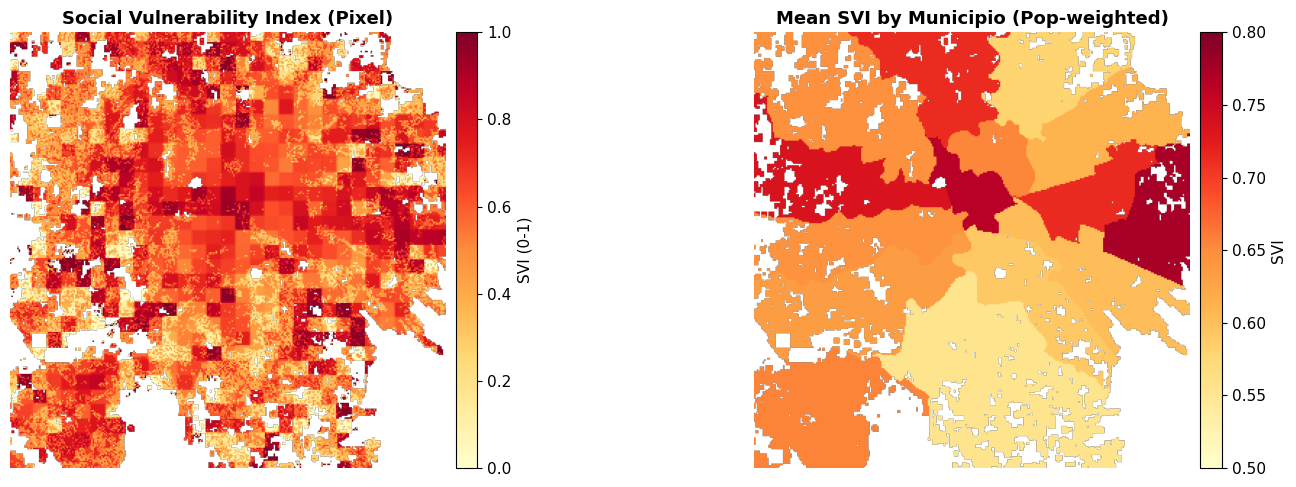

In [77]:
# Visualize SVI by Municipio 
if HAS_VULN:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. SVI Raster
    ax1 = axes[0]
    svi_plot = np.where(MASK_POLICY & np.isfinite(svi_on_ref), svi_on_ref, np.nan)
    im1 = ax1.imshow(svi_plot, cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_title('Social Vulnerability Index (Pixel)', fontweight='bold')
    ax1.axis('off')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im1, cax=cax1, label='SVI (0-1)')
    
    # 2. SVI by Municipio
    ax2 = axes[1]
    svi_by_muni = np.full_like(svi_on_ref, np.nan)
    for _, row in policy_df.iterrows():
        mid = int(row["muni_id"])
        svi_by_muni[muni_on_ref == mid] = row["svi_popw"]
    svi_by_muni = np.where(MASK_POLICY, svi_by_muni, np.nan)
    im2 = ax2.imshow(svi_by_muni, cmap='YlOrRd', vmin=0.5, vmax=0.8)
    ax2.set_title('Mean SVI by Municipio (Pop-weighted)', fontweight='bold')
    ax2.axis('off')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im2, cax=cax2, label='SVI')
    
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_svi_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

### 4.3 Equity-Weighted Policy

Alternative allocation that prioritizes high-vulnerability (high-SVI) areas
among those needing greening (low-GVI).

In [78]:
# Equity Policy: Target high-SVI AND low-GVI areas 

equity_df = None
yr_totals_equity = None
dGVI_map_equity = None
dT_monthly_eq = None
dT_summer_eq = None
avo_equity = None

if HAS_VULN and "svi_popw" in policy_df.columns:
    
    TOTAL_BUDGET = float(policy_df["dGVI"].sum())
    
    def allocate_equity_smart(muni_df, total_budget):
        """
        Smart equity allocation: prioritize areas with high SVI AND low GVI.
        
        Logic: 
        - Only allocate to areas below target GVI (like uniform)
        - Among those, prioritize by SVI
        """
        df = muni_df.copy()
        
        # Identify areas that need greening (below target)
        needs_greening = df["gvi_mean"] < TARGET_GVI
        
        if needs_greening.sum() == 0:
            df["dGVI_equity"] = 0.0
            df["gvi_after_equity"] = df["gvi_mean"]
            return df
        
        # Among areas needing greening, weight by SVI (higher SVI = higher priority)
        df["needs_greening"] = needs_greening
        df["svi_weight"] = np.where(needs_greening, df["svi_popw"], 0.0)
        
        # Normalize weights
        weight_sum = df["svi_weight"].sum()
        if weight_sum > 0:
            df["weight_norm"] = df["svi_weight"] / weight_sum
        else:
            df["weight_norm"] = 0.0
        
        # Allocate budget proportionally to SVI weight (only to needy areas)
        df["dGVI_equity"] = df["weight_norm"] * total_budget
        df["gvi_after_equity"] = df["gvi_mean"] + df["dGVI_equity"]
        
        return df.drop(columns=["needs_greening", "svi_weight", "weight_norm"]).sort_values("muni_id").reset_index(drop=True)
    
    # Apply smart equity allocation
    equity_df = allocate_equity_smart(policy_df, TOTAL_BUDGET)
    
    print(f"\n=== Smart Equity Policy (High-SVI among low-GVI areas) ===")
    print(f"Total ΔGVI budget: {TOTAL_BUDGET:.2f} points (same as uniform)")
    print(f"Target GVI: {TARGET_GVI:.2f}")
    
    cols_eq = ["muni_id", "muni_name", "gvi_mean", "svi_popw", "dGVI", "dGVI_equity"]
    print(equity_df[cols_eq].round(3).to_string(index=False))
    
    # Compare allocations
    print("\n--- Allocation Comparison ---")
    print("Municipio          | GVI   | SVI   | dGVI_uniform | dGVI_equity")
    print("-" * 65)
    for _, row in equity_df.iterrows():
        print(f"{row['muni_name']:18s} | {row['gvi_mean']:5.1f} | {row['svi_popw']:.3f} | {row['dGVI']:12.2f} | {row['dGVI_equity']:.2f}")
    
    # Build equity ΔGVI map
    dgvi_lut_eq = {int(row.muni_id): float(row.dGVI_equity) for row in equity_df.itertuples()}
    lut_size = int(muni_on_ref.max()) + 1
    dgvi_lut_eq_arr = np.zeros(lut_size, dtype=float)
    for mid, dg in dgvi_lut_eq.items():
        if mid < lut_size:
            dgvi_lut_eq_arr[mid] = dg
    
    dGVI_map_equity = np.where(SCOPE_PHYS, dgvi_lut_eq_arr[muni_on_ref], 0.0)
    
    # Compute cooling for equity policy (monthly by LCZ)
    dT_monthly_eq = compute_monthly_dT(dGVI_map_equity, lcz_on_ref, SCOPE_PHYS, coef_lut)
    dT_summer_eq = dT_monthly_eq[summer_indices].mean(axis=0)  # For reporting
    
    dT_equity_popw = compute_popw_mean(dT_summer_eq, pop_on_ref, SCOPE_PHYS)
    dT_uniform_popw = compute_popw_mean(dT_summer, pop_on_ref, SCOPE_PHYS)
    
    print(f"\nSummer ΔT (pop-weighted):")
    print(f"  Uniform: {dT_uniform_popw:.4f} °C")
    print(f"  Equity:  {dT_equity_popw:.4f} °C")
    
    # Compute deaths for equity policy (using monthly cooling)
    print("\nComputing equity policy deaths...")
    yr_rates_equity, yr_totals_equity = annual_deaths_with_ac_and_dT(
        H, dT_monthly_eq, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year
    )
    
    # Avoided deaths comparison
    avo_equity = yr_totals_base - yr_totals_equity
    
    print("\n=== Avoided Deaths: Uniform vs Smart Equity ===")
    comparison = pd.DataFrame({
        "year": yr_totals_base.index,
        "baseline": yr_totals_base["overall"].values,
        "uniform": yr_totals_trees["overall"].values,
        "equity": yr_totals_equity["overall"].values,
        "avo_uniform": avo_trees["avo_overall"].values,
        "avo_equity": avo_equity["overall"].values,
    })
    comparison["diff"] = comparison["avo_equity"] - comparison["avo_uniform"]
    comparison["pct_diff"] = (comparison["diff"] / comparison["avo_uniform"] * 100).round(1)
    print(comparison.round(3).to_string(index=False))
    
    # Update tables dict
    tables["yr_totals_equity"] = yr_totals_equity
    tables["yr_rates_equity"] = yr_rates_equity
    tables["avo_equity"] = avo_equity
    tables["equity_df"] = equity_df
    tables["dGVI_map_equity"] = dGVI_map_equity
    tables["dT_monthly_eq"] = dT_monthly_eq    # (full monthly data)
    tables["dT_summer_eq"] = dT_summer_eq      # Keep (for reporting/viz)

else:
    print("\n[SKIP] Equity policy not computed (SVI not available)")


=== Smart Equity Policy (High-SVI among low-GVI areas) ===
Total ΔGVI budget: 23.10 points (same as uniform)
Target GVI: 21.30
 muni_id           muni_name  gvi_mean  svi_popw  dGVI  dGVI_equity
       1    Municipio Roma I    16.390     0.764 4.910        2.242
       2   Municipio Roma II    19.834     0.654 1.466        1.918
       3  Municipio Roma III    20.959     0.579 0.341        1.698
       4   Municipio Roma IV    18.183     0.611 3.117        1.792
       5    Municipio Roma V    16.397     0.713 4.903        2.093
       6   Municipio Roma VI    18.435     0.775 2.865        2.272
       7  Municipio Roma VII    19.071     0.601 2.229        1.763
       8 Municipio Roma VIII    21.182     0.591 0.118        1.733
       9   Municipio Roma IX    20.961     0.555 0.339        1.628
      10    Municipio Roma X    20.778     0.655 0.522        1.921
      11   Municipio Roma XI    23.969     0.633 0.000        0.000
      12  Municipio Roma XII    21.437     0.644 0.000  

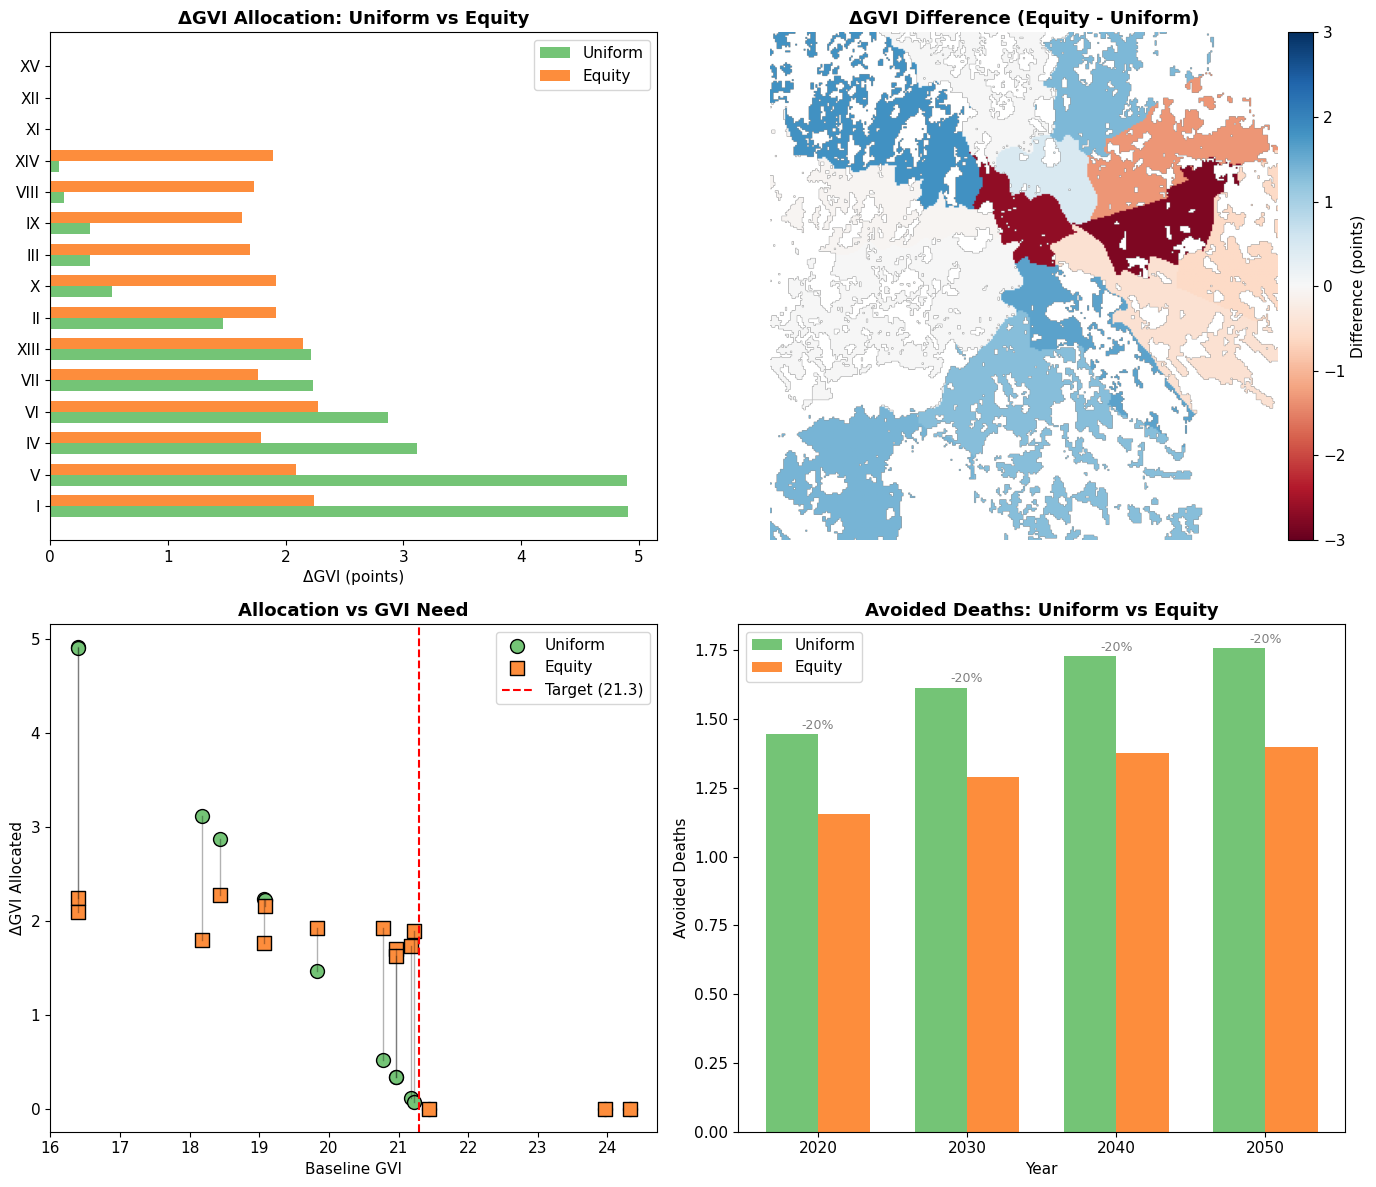

In [79]:
# Visualize Uniform vs Equity Policy Allocation 

if HAS_VULN and equity_df is not None and dGVI_map_equity is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. ΔGVI comparison bar chart
    ax1 = axes[0, 0]
    x = np.arange(len(equity_df))
    width = 0.35
    
    eq_sorted = equity_df.sort_values('dGVI', ascending=False)
    bars1 = ax1.barh(x - width/2, eq_sorted['dGVI'], width, 
                     label='Uniform', color='#74c476')
    bars2 = ax1.barh(x + width/2, eq_sorted['dGVI_equity'], width, 
                     label='Equity', color='#fd8d3c')
    
    ax1.set_yticks(x)
    ax1.set_yticklabels([n.replace('Municipio Roma ', '') for n in eq_sorted['muni_name']])
    ax1.set_xlabel('ΔGVI (points)')
    ax1.set_title('ΔGVI Allocation: Uniform vs Equity', fontweight='bold')
    ax1.legend()
    ax1.axvline(0, color='black', linewidth=0.5)
    
    # 2. Maps comparison - Difference map (Equity - Uniform)
    ax2 = axes[0, 1]
    
    dgvi_diff = dGVI_map_equity - dGVI_map
    dgvi_diff_plot = np.where(SCOPE_PHYS, dgvi_diff, np.nan)
    im2 = ax2.imshow(dgvi_diff_plot, cmap='RdBu', vmin=-3, vmax=3)
    ax2.set_title('ΔGVI Difference (Equity - Uniform)', fontweight='bold')
    ax2.axis('off')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im2, cax=cax2, label='Difference (points)')
    
    # 3. Allocation vs Need scatter
    ax3 = axes[1, 0]
    ax3.scatter(equity_df['gvi_mean'], equity_df['dGVI'], s=100, 
                label='Uniform', color='#74c476', edgecolors='black', marker='o')
    ax3.scatter(equity_df['gvi_mean'], equity_df['dGVI_equity'], s=100, 
                label='Equity', color='#fd8d3c', edgecolors='black', marker='s')
    
    # Connect with lines
    for _, row in equity_df.iterrows():
        ax3.plot([row['gvi_mean'], row['gvi_mean']], 
                [row['dGVI'], row['dGVI_equity']], 
                'k-', alpha=0.3, linewidth=1)
    
    ax3.axvline(TARGET_GVI, color='red', linestyle='--', label=f'Target ({TARGET_GVI:.1f})')
    ax3.set_xlabel('Baseline GVI')
    ax3.set_ylabel('ΔGVI Allocated')
    ax3.set_title('Allocation vs GVI Need', fontweight='bold')
    ax3.legend()
    
    # 4. Avoided deaths comparison
    ax4 = axes[1, 1]
    years = yr_totals_base.index.tolist()
    x = np.arange(len(years))
    width = 0.35
    
    ax4.bar(x - width/2, avo_trees['avo_overall'], width, 
            label='Uniform', color='#74c476')
    ax4.bar(x + width/2, avo_equity['overall'], width, 
            label='Equity', color='#fd8d3c')
    
    ax4.set_xticks(x)
    ax4.set_xticklabels(years)
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Avoided Deaths')
    ax4.set_title('Avoided Deaths: Uniform vs Equity', fontweight='bold')
    ax4.legend()
    
    # Add percentage difference
    for i, (u, e) in enumerate(zip(avo_trees['avo_overall'], avo_equity['overall'])):
        pct = (e - u) / u * 100
        ax4.annotate(f'{pct:.0f}%', (i, max(u, e) + 0.02), 
                    ha='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_uniform_vs_equity.png", dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("[SKIP] Equity visualization not available (missing data)")

### 4.4 Disparity Analysis

Compare death rates and benefits across SVI quintiles.

In [80]:
# Disparity Analysis: Uniform vs Smart Equity (Population Quintiles) 
if HAS_VULN and yr_totals_equity is not None:
    
    print("\n" + "="*80)
    print("DISPARITY ANALYSIS: Deaths by SVI Quintile (Population-Weighted)")
    print("="*80)
    
    # Build POPULATION-WEIGHTED SVI quintiles 
    mask_valid = SCOPE_PHYS & np.isfinite(svi_on_ref) & (pop_on_ref > 0)
    
    rows_valid, cols_valid = np.where(mask_valid)
    svi_flat = svi_on_ref[mask_valid]
    pop_flat = pop_on_ref[mask_valid]
    
    sort_idx = np.argsort(svi_flat)
    svi_sorted = svi_flat[sort_idx]
    pop_sorted = pop_flat[sort_idx]
    rows_sorted = rows_valid[sort_idx]
    cols_sorted = cols_valid[sort_idx]
    
    cumsum_pop = np.cumsum(pop_sorted)
    total_pop = cumsum_pop[-1]
    cumfrac = cumsum_pop / total_pop
    
    quintile_flat = np.zeros(len(svi_sorted), dtype=int)
    for i, frac in enumerate(cumfrac):
        if frac <= 0.2:
            quintile_flat[i] = 1
        elif frac <= 0.4:
            quintile_flat[i] = 2
        elif frac <= 0.6:
            quintile_flat[i] = 3
        elif frac <= 0.8:
            quintile_flat[i] = 4
        else:
            quintile_flat[i] = 5
    
    svi_quintile = np.zeros_like(svi_on_ref, dtype=int)
    for idx in range(len(rows_sorted)):
        svi_quintile[rows_sorted[idx], cols_sorted[idx]] = quintile_flat[idx]
    
    # SVI thresholds
    quintile_thresholds_pop = []
    for q in range(1, 5):
        mask_q = quintile_flat == q
        if mask_q.any():
            quintile_thresholds_pop.append(svi_sorted[mask_q].max())
    quintile_thresholds_pop = np.array(quintile_thresholds_pop)
    
    print(f"\nPopulation-weighted SVI quintile thresholds: {quintile_thresholds_pop.round(3)}")
    
    pop_per_q = [float(np.nansum(pop_on_ref[svi_quintile == q])) for q in range(1, 6)]
    print(f"Population per quintile: {[f'{p/1e3:.0f}k' for p in pop_per_q]}")
    
    # Compute deaths by quintile 
    def compute_deaths_by_quintile(H, dT_monthly, coverage_by_year, age_by_year, quintile_grid, year):
        """
        Compute deaths by SVI quintile for a specific year.
        
        Parameters:
        -----------
        dT_monthly : array (12, H, W) - monthly cooling grids
                     OR (H, W) for backward compatibility
        """
        dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
        rows_year = np.where(dates.dt.year.to_numpy(int) == int(year))[0]
        
        grid_shape = MASK_POLICY.shape
        deaths_by_q = {q: 0.0 for q in range(1, 6)}
        pop_by_q = {q: 0.0 for q in range(1, 6)}
        
        for q in range(1, 6):
            mask_q = (quintile_grid == q) & SCOPE_PHYS
            pop_by_q[q] = float(np.nansum(np.nan_to_num(pop_on_ref_by_year[year], 0.0)[mask_q]))
        
        cov_y = np.nan_to_num(coverage_by_year.get(year, np.zeros(grid_shape)).astype(float), nan=0.0)
        age_ifs_y = get_age_ifs_for_year(year)
        
        # Check if dT_monthly is (12, H, W) or just (H, W)
        if dT_monthly.ndim == 3:
            use_monthly = True
        else:
            use_monthly = False
            dT_fixed = dT_monthly
        
        for i_ev in rows_year:
            d = dates.iloc[i_ev]
            I_grid = _row_to_grid(H.intensity, i_ev, grid_shape)
            
            # Get month-specific offset
            if use_monthly:
                month_idx = d.month - 1  # 0-indexed
                dT_offset = dT_monthly[month_idx]
            else:
                dT_offset = dT_fixed
            
            I_policy = I_grid + dT_offset
            
            for age_lbl, f in age_ifs_y.items():
                mdd = np.interp(I_policy, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
                eff_a = _eff_for_age(age_lbl)
                mult = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)
                pop_a = np.nan_to_num(age_by_year[year][age_lbl], 0.0)
                deaths_grid = np.where(SCOPE_PHYS, pop_a * mdd * mult, 0.0)
                
                for q in range(1, 6):
                    mask_q = (quintile_grid == q) & SCOPE_PHYS
                    deaths_by_q[q] += float(np.nansum(deaths_grid[mask_q]))
        
        return deaths_by_q, pop_by_q
    
    FOCUS_YEAR = max(YEARS_H)
    print(f"\nAnalyzing year: {FOCUS_YEAR}")
    
    # Three scenarios
    deaths_base_q, pop_q = compute_deaths_by_quintile(
        H, dT_zero, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR
    )
    deaths_uniform_q, _ = compute_deaths_by_quintile(
        H, dT_monthly, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR  
    )
    deaths_equity_q, _ = compute_deaths_by_quintile(
        H, dT_monthly_eq, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR  
    )
    
    # Results table
    disparity_df = pd.DataFrame({
        "quintile": range(1, 6),
        "svi_label": ["Q1 (lowest SVI)", "Q2", "Q3", "Q4", "Q5 (highest SVI)"],
        "population": [pop_q[q] for q in range(1, 6)],
        "deaths_baseline": [deaths_base_q[q] for q in range(1, 6)],
        "deaths_uniform": [deaths_uniform_q[q] for q in range(1, 6)],
        "deaths_equity": [deaths_equity_q[q] for q in range(1, 6)],
    })
    
    disparity_df["rate_baseline"] = disparity_df["deaths_baseline"] / disparity_df["population"] * 1e5
    disparity_df["rate_uniform"] = disparity_df["deaths_uniform"] / disparity_df["population"] * 1e5
    disparity_df["rate_equity"] = disparity_df["deaths_equity"] / disparity_df["population"] * 1e5
    
    disparity_df["avo_uniform"] = disparity_df["deaths_baseline"] - disparity_df["deaths_uniform"]
    disparity_df["avo_equity"] = disparity_df["deaths_baseline"] - disparity_df["deaths_equity"]
    
    disparity_df["avo_rate_uniform"] = disparity_df["avo_uniform"] / disparity_df["population"] * 1e5
    disparity_df["avo_rate_equity"] = disparity_df["avo_equity"] / disparity_df["population"] * 1e5
    
    print("\n--- Deaths and Rates by SVI Quintile ---")
    cols_show = ["svi_label", "population", "rate_baseline", "avo_uniform", "avo_equity", 
                 "avo_rate_uniform", "avo_rate_equity"]
    print(disparity_df[cols_show].round(3).to_string(index=False))
    
    # Disparity ratios (Q5/Q1) 
    Q1_base = disparity_df.loc[disparity_df["quintile"] == 1, "rate_baseline"].values[0]
    Q5_base = disparity_df.loc[disparity_df["quintile"] == 5, "rate_baseline"].values[0]
    Q1_unif = disparity_df.loc[disparity_df["quintile"] == 1, "rate_uniform"].values[0]
    Q5_unif = disparity_df.loc[disparity_df["quintile"] == 5, "rate_uniform"].values[0]
    Q1_eq = disparity_df.loc[disparity_df["quintile"] == 1, "rate_equity"].values[0]
    Q5_eq = disparity_df.loc[disparity_df["quintile"] == 5, "rate_equity"].values[0]
    
    ratio_baseline = Q5_base / Q1_base if Q1_base > 0 else np.nan
    ratio_uniform = Q5_unif / Q1_unif if Q1_unif > 0 else np.nan
    ratio_equity = Q5_eq / Q1_eq if Q1_eq > 0 else np.nan
    
    print("\n" + "="*60)
    print("DISPARITY RATIO (Q5/Q1 death rate)")
    print("="*60)
    print(f"  Baseline:       {ratio_baseline:.4f}")
    print(f"  Uniform policy: {ratio_uniform:.4f}  (Δ = {ratio_uniform - ratio_baseline:+.5f})")
    print(f"  Equity policy:  {ratio_equity:.4f}  (Δ = {ratio_equity - ratio_baseline:+.5f})")
    
    if ratio_baseline > 1:
        excess = ratio_baseline - 1
        red_unif = (ratio_baseline - ratio_uniform) / excess * 100
        red_eq = (ratio_baseline - ratio_equity) / excess * 100
        print(f"\n  Disparity reduction (towards ratio=1):")
        print(f"    Uniform: {red_unif:+.2f}%")
        print(f"    Equity:  {red_eq:+.2f}%")
    
    # Distribution of benefits 
    total_avo_unif = disparity_df["avo_uniform"].sum()
    total_avo_eq = disparity_df["avo_equity"].sum()
    
    disparity_df["share_uniform"] = disparity_df["avo_uniform"] / total_avo_unif * 100
    disparity_df["share_equity"] = disparity_df["avo_equity"] / total_avo_eq * 100
    
    print("\n" + "="*60)
    print("DISTRIBUTION OF AVOIDED DEATHS")
    print("="*60)
    print("\n  % of avoided deaths by quintile:")
    for _, row in disparity_df.iterrows():
        print(f"    {row['svi_label']:17s}: Uniform {row['share_uniform']:5.1f}%  |  Equity {row['share_equity']:5.1f}%")
    
    high_vuln_unif = disparity_df.loc[disparity_df["quintile"] >= 4, "avo_uniform"].sum()
    high_vuln_eq = disparity_df.loc[disparity_df["quintile"] >= 4, "avo_equity"].sum()
    
    print(f"\n  Benefits to most vulnerable 40% (Q4+Q5):")
    print(f"    Uniform: {high_vuln_unif:.3f} deaths ({high_vuln_unif/total_avo_unif*100:.1f}%)")
    print(f"    Equity:  {high_vuln_eq:.3f} deaths ({high_vuln_eq/total_avo_eq*100:.1f}%)")
    
    # Final summary 
    print("\n" + "="*60)
    print("EQUITY-EFFICIENCY TRADE-OFF SUMMARY")
    print("="*60)
    
    print(f"\n  EFFICIENCY (total avoided deaths):")
    print(f"    Uniform: {total_avo_unif:.3f}")
    print(f"    Equity:  {total_avo_eq:.3f}  ({(total_avo_eq/total_avo_unif - 1)*100:+.1f}%)")
    
    print(f"\n  EQUITY (Q5/Q1 disparity ratio):")
    print(f"    Baseline: {ratio_baseline:.4f}")
    print(f"    Uniform:  {ratio_uniform:.4f}  ({red_unif:+.1f}% reduction)")
    print(f"    Equity:   {ratio_equity:.4f}  ({red_eq:+.1f}% reduction)")
    
    print(f"\n  TARGETING (share to Q4+Q5):")
    print(f"    Uniform: {high_vuln_unif/total_avo_unif*100:.1f}%")
    print(f"    Equity:  {high_vuln_eq/total_avo_eq*100:.1f}%")
    
    # Store
    tables["disparity_df"] = disparity_df
    tables["disparity_ratios"] = {
        "baseline": ratio_baseline,
        "uniform": ratio_uniform,
        "equity": ratio_equity,
    }
    tables["svi_quintile_grid"] = svi_quintile

else:
    print("\n[SKIP] Disparity analysis not computed")


DISPARITY ANALYSIS: Deaths by SVI Quintile (Population-Weighted)

Population-weighted SVI quintile thresholds: [0.555 0.625 0.69  0.769]
Population per quintile: ['482k', '482k', '482k', '482k', '482k']

Analyzing year: 2050

--- Deaths and Rates by SVI Quintile ---
       svi_label  population  rate_baseline  avo_uniform  avo_equity  avo_rate_uniform  avo_rate_equity
 Q1 (lowest SVI)  446309.188         24.307        0.087       0.169             0.019            0.038
              Q2  446191.531         24.336        0.233       0.254             0.052            0.057
              Q3  446299.875         24.071        0.318       0.259             0.071            0.058
              Q4  446454.125         25.064        0.380       0.282             0.085            0.063
Q5 (highest SVI)  446505.844         25.451        0.739       0.436             0.166            0.098

DISPARITY RATIO (Q5/Q1 death rate)
  Baseline:       1.0471
  Uniform policy: 1.0411  (Δ = -0.00597)
  Equi

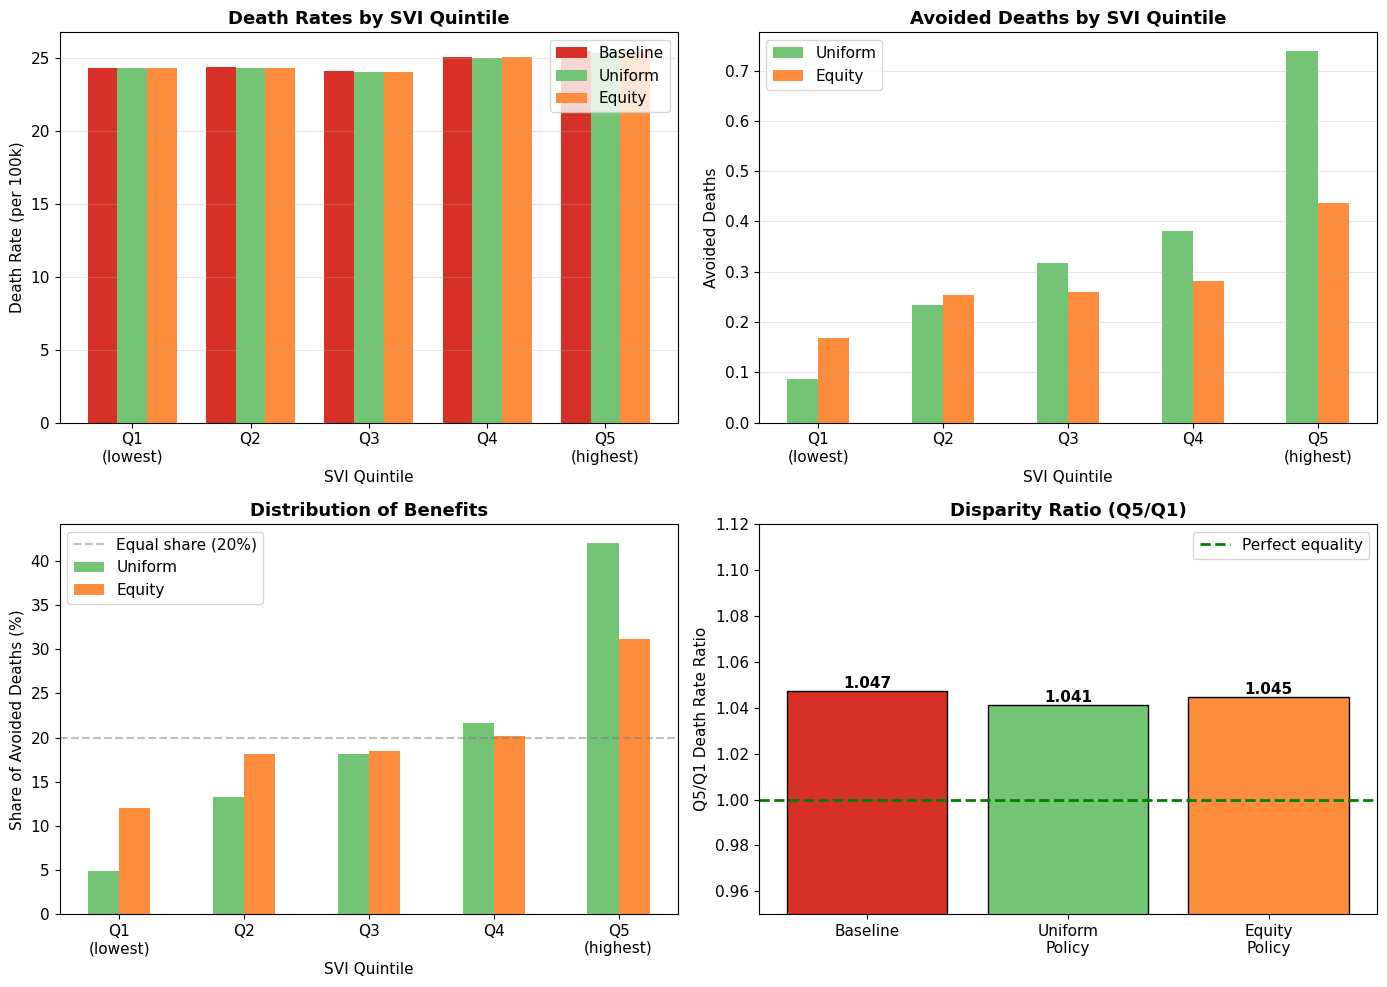

In [81]:
# Visualize Disparity Analysis 
if HAS_VULN and 'disparity_df' in tables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    disp_df = tables['disparity_df']
    
    # 1. Death rates by quintile
    ax1 = axes[0, 0]
    x = np.arange(5)
    width = 0.25
    
    ax1.bar(x - width, disp_df['rate_baseline'], width, label='Baseline', color='#d73027')
    ax1.bar(x, disp_df['rate_uniform'], width, label='Uniform', color='#74c476')
    ax1.bar(x + width, disp_df['rate_equity'], width, label='Equity', color='#fd8d3c')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax1.set_xlabel('SVI Quintile')
    ax1.set_ylabel('Death Rate (per 100k)')
    ax1.set_title('Death Rates by SVI Quintile', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Avoided deaths by quintile
    ax2 = axes[0, 1]
    ax2.bar(x - width/2, disp_df['avo_uniform'], width, label='Uniform', color='#74c476')
    ax2.bar(x + width/2, disp_df['avo_equity'], width, label='Equity', color='#fd8d3c')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax2.set_xlabel('SVI Quintile')
    ax2.set_ylabel('Avoided Deaths')
    ax2.set_title('Avoided Deaths by SVI Quintile', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Share of benefits (pie charts)
    ax3 = axes[1, 0]
    
    # Create grouped bar for share comparison
    share_unif = disp_df['share_uniform'].values
    share_eq = disp_df['share_equity'].values
    
    ax3.bar(x - width/2, share_unif, width, label='Uniform', color='#74c476')
    ax3.bar(x + width/2, share_eq, width, label='Equity', color='#fd8d3c')
    
    ax3.axhline(20, color='gray', linestyle='--', alpha=0.5, label='Equal share (20%)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax3.set_xlabel('SVI Quintile')
    ax3.set_ylabel('Share of Avoided Deaths (%)')
    ax3.set_title('Distribution of Benefits', fontweight='bold')
    ax3.legend()
    
    # 4. Disparity ratio visualization
    ax4 = axes[1, 1]
    ratios = [ratio_baseline, ratio_uniform, ratio_equity]
    labels = ['Baseline', 'Uniform\nPolicy', 'Equity\nPolicy']
    colors = ['#d73027', '#74c476', '#fd8d3c']
    
    bars = ax4.bar(labels, ratios, color=colors, edgecolor='black', linewidth=1)
    ax4.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect equality')
    ax4.set_ylabel('Q5/Q1 Death Rate Ratio')
    ax4.set_title('Disparity Ratio (Q5/Q1)', fontweight='bold')
    ax4.set_ylim(0.95, 1.12)
    ax4.legend()
    
    # Add value labels
    for bar, ratio in zip(bars, ratios):
        ax4.annotate(f'{ratio:.3f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_disparity_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

### 4.5 GVI-SVI Correlation

Examine the relationship between green cover and vulnerability.

In [82]:
# Check GVI-SVI correlation at Municipio level
if HAS_VULN and "svi_popw" in policy_df.columns:
    corr = policy_df[["gvi_mean", "svi_popw"]].corr().iloc[0, 1]
    print(f"GVI-SVI correlation: {corr:.3f}")
    
    print("\n" + "="*70)
    print("KEY FINDING: GVI-SVI SPATIAL CORRELATION")
    print("="*70)
    print(f"  Correlation (Municipio-level): ρ = {corr:.3f}")
    
    if corr < -0.2:
        print("  Interpretation: NEGATIVE correlation")
        print("  → Low-GVI areas tend to have high SVI (vulnerable populations)")
        print("  → Uniform policy naturally benefits vulnerable areas")
    elif corr > 0.2:
        print("  Interpretation: POSITIVE correlation")
        print("  → High-GVI areas have high SVI (unexpected)")
        print("  → Equity policy needed to redirect benefits")
    else:
        print("  Interpretation: WEAK correlation")
        print("  → GVI and SVI are spatially independent")
        print("  → Equity weighting can improve targeting")

GVI-SVI correlation: -0.387

KEY FINDING: GVI-SVI SPATIAL CORRELATION
  Correlation (Municipio-level): ρ = -0.387
  Interpretation: NEGATIVE correlation
  → Low-GVI areas tend to have high SVI (vulnerable populations)
  → Uniform policy naturally benefits vulnerable areas


In [83]:
# Key Finding: GVI-SVI Correlation 
corr_gvi_svi = policy_df[["gvi_mean", "svi_popw"]].corr().iloc[0, 1]

print("\n" + "="*70)
print("KEY FINDING: GVI-SVI SPATIAL CORRELATION")
print("="*70)
print(f"\n  Correlation (Municipio-level): ρ = {corr_gvi_svi:.3f}")

if corr_gvi_svi < -0.2:
    print(f"\n  Interpretation: NEGATIVE correlation")
    print(f"    → Low greenery areas have higher social vulnerability")
    print(f"    → Uniform GVI policy naturally targets vulnerable populations")
    print(f"    → No equity-efficiency trade-off for vegetation policy")
elif corr_gvi_svi > 0.2:
    print(f"\n  Interpretation: POSITIVE correlation")
    print(f"    → High greenery areas have higher social vulnerability")
    print(f"    → Uniform GVI policy may miss vulnerable populations")
    print(f"    → Explicit equity targeting may be needed")
else:
    print(f"\n  Interpretation: WEAK correlation")
    print(f"    → GVI and SVI are spatially independent")
    print(f"    → Policy choice depends on priorities")

print(f"\n  Policy recommendation for Rome:")
print(f"    → Use uniform 'close-the-gap' policy (target = Q3 GVI)")
print(f"    → Achieves {ratio_baseline - ratio_uniform:.4f} disparity reduction")
print(f"    → Concentrates {high_vuln_unif/total_avo_unif*100:.0f}% of benefits in Q4+Q5")

# Store
tables["gvi_svi_correlation"] = corr_gvi_svi


KEY FINDING: GVI-SVI SPATIAL CORRELATION

  Correlation (Municipio-level): ρ = -0.387

  Interpretation: NEGATIVE correlation
    → Low greenery areas have higher social vulnerability
    → Uniform GVI policy naturally targets vulnerable populations
    → No equity-efficiency trade-off for vegetation policy

  Policy recommendation for Rome:
    → Use uniform 'close-the-gap' policy (target = Q3 GVI)
    → Achieves 0.0060 disparity reduction
    → Concentrates 64% of benefits in Q4+Q5


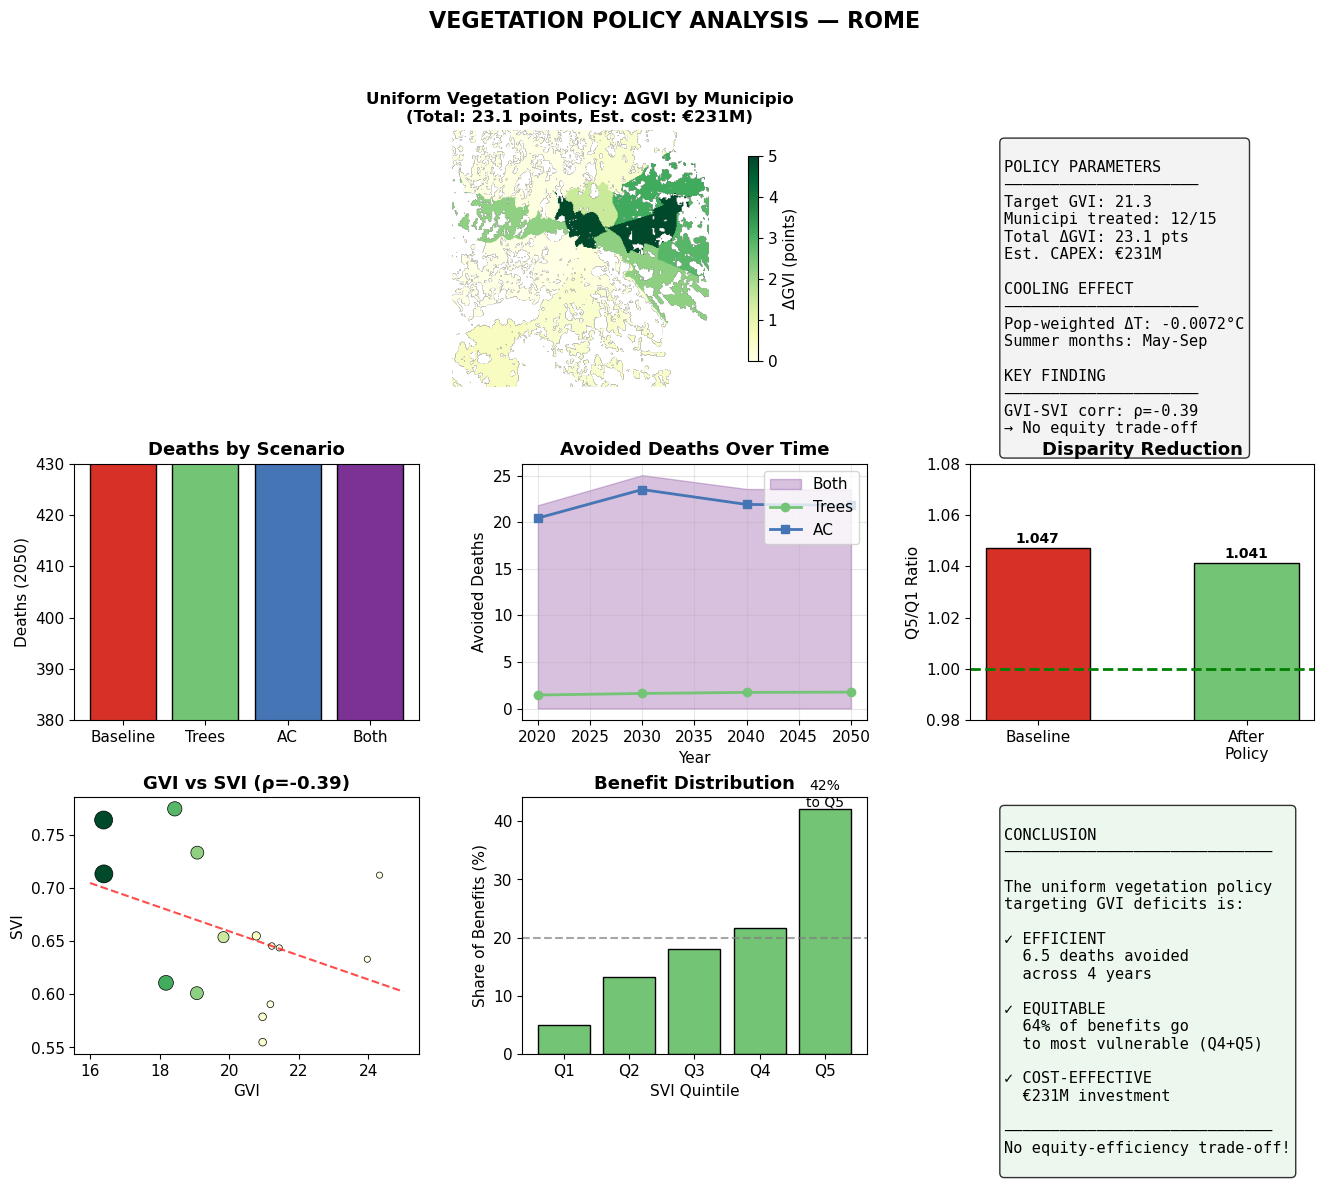


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_policy_summary.png


In [84]:
# Summary Infographic 
fig = plt.figure(figsize=(16, 12))

# Create grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Policy overview map (large)
ax1 = fig.add_subplot(gs[0, :2])
dgvi_plot = np.where(SCOPE_PHYS, dGVI_map, np.nan)
im1 = ax1.imshow(dgvi_plot, cmap='YlGn', vmin=0, vmax=5)
ax1.set_title(f'Uniform Vegetation Policy: ΔGVI by Municipio\n(Total: {total_dGVI:.1f} points, Est. cost: €{total_dGVI*10:.0f}M)', 
              fontweight='bold', fontsize=12)
ax1.axis('off')
plt.colorbar(im1, ax=ax1, label='ΔGVI (points)', shrink=0.8)

# 2. Key metrics box
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = f"""
POLICY PARAMETERS
─────────────────────
Target GVI: {TARGET_GVI:.1f}
Municipi treated: {n_treated}/15
Total ΔGVI: {total_dGVI:.1f} pts
Est. CAPEX: €{total_dGVI*10:.0f}M

COOLING EFFECT
─────────────────────
Pop-weighted ΔT: {dT_summer_popw:.4f}°C
Summer months: May-Sep

KEY FINDING
─────────────────────
GVI-SVI corr: ρ={corr_gvi_svi:.2f}
→ No equity trade-off
"""
ax2.text(0.1, 0.95, metrics_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

# 3. Deaths comparison
ax3 = fig.add_subplot(gs[1, 0])
scenarios = ['Baseline', 'Trees', 'AC', 'Both']
deaths_2050 = [yr_totals_base.loc[2050, 'overall'],
               yr_totals_trees.loc[2050, 'overall'],
               yr_totals_acpol.loc[2050, 'overall'],
               yr_totals_both.loc[2050, 'overall']]
colors = ['#d73027', '#74c476', '#4575b4', '#7b3294']
ax3.bar(scenarios, deaths_2050, color=colors, edgecolor='black')
ax3.set_ylabel('Deaths (2050)')
ax3.set_title('Deaths by Scenario', fontweight='bold')
ax3.set_ylim(380, 430)

# 4. Avoided deaths time series
ax4 = fig.add_subplot(gs[1, 1])
years = yr_totals_base.index.tolist()
ax4.fill_between(years, 0, avo_both['avo_overall'], alpha=0.3, color='#7b3294', label='Both')
ax4.plot(years, avo_trees['avo_overall'], 'o-', color='#74c476', label='Trees', linewidth=2)
ax4.plot(years, avo_ac['avo_overall'], 's-', color='#4575b4', label='AC', linewidth=2)
ax4.set_xlabel('Year')
ax4.set_ylabel('Avoided Deaths')
ax4.set_title('Avoided Deaths Over Time', fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# 5. Disparity reduction
ax5 = fig.add_subplot(gs[1, 2])
ratios = [ratio_baseline, ratio_uniform]
labels = ['Baseline', 'After\nPolicy']
colors = ['#d73027', '#74c476']
bars = ax5.bar(labels, ratios, color=colors, edgecolor='black', width=0.5)
ax5.axhline(1.0, color='green', linestyle='--', linewidth=2)
ax5.set_ylabel('Q5/Q1 Ratio')
ax5.set_title('Disparity Reduction', fontweight='bold')
ax5.set_ylim(0.98, 1.08)
for bar, ratio in zip(bars, ratios):
    ax5.annotate(f'{ratio:.3f}', (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002),
                ha='center', fontsize=10, fontweight='bold')

# 6. GVI vs SVI scatter
ax6 = fig.add_subplot(gs[2, 0])
scatter = ax6.scatter(policy_df['gvi_mean'], policy_df['svi_popw'], 
                      s=policy_df['dGVI']*30 + 20, c=policy_df['dGVI'], 
                      cmap='YlGn', edgecolors='black', linewidth=0.5,
                      vmin=0, vmax=5)
z = np.polyfit(policy_df['gvi_mean'], policy_df['svi_popw'], 1)
p = np.poly1d(z)
x_line = np.linspace(16, 25, 100)
ax6.plot(x_line, p(x_line), 'r--', alpha=0.7)
ax6.set_xlabel('GVI')
ax6.set_ylabel('SVI')
ax6.set_title(f'GVI vs SVI (ρ={corr_gvi_svi:.2f})', fontweight='bold')

# 7. Benefits distribution
ax7 = fig.add_subplot(gs[2, 1])
quintiles = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
ax7.bar(quintiles, disp_df['share_uniform'], color='#74c476', edgecolor='black')
ax7.axhline(20, color='gray', linestyle='--', alpha=0.7)
ax7.set_ylabel('Share of Benefits (%)')
ax7.set_xlabel('SVI Quintile')
ax7.set_title('Benefit Distribution', fontweight='bold')
ax7.annotate(f'{disp_df["share_uniform"].iloc[4]:.0f}%\nto Q5', 
             xy=(4, disp_df['share_uniform'].iloc[4]), 
             fontsize=10, ha='center', va='bottom')

# 8. Summary conclusion
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
conclusion = f"""
CONCLUSION
─────────────────────────────

The uniform vegetation policy
targeting GVI deficits is:

✓ EFFICIENT
  {avo_trees["avo_overall"].sum():.1f} deaths avoided
  across {len(YEARS_H)} years

✓ EQUITABLE  
  {high_vuln_unif/total_avo_unif*100:.0f}% of benefits go
  to most vulnerable (Q4+Q5)

✓ COST-EFFECTIVE
  €{total_dGVI*10:.0f}M investment
  
─────────────────────────────
No equity-efficiency trade-off!
"""
ax8.text(0.1, 0.95, conclusion, transform=ax8.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8))

plt.suptitle(f'VEGETATION POLICY ANALYSIS — {CITY.upper()}', fontsize=16, fontweight='bold', y=0.98)
plt.savefig(OUT / f"{SLUG}_policy_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUT / f'{SLUG}_policy_summary.png'}")

In [85]:
TBL = OUT / "tables"
TBL.mkdir(parents=True, exist_ok=True)

# Policy Comparison Table 
if HAS_VULN and equity_df is not None:
    
    # Create comprehensive comparison table
    comparison_tbl = equity_df[['muni_id', 'muni_name', 'gvi_mean', 'svi_popw', 
                                 'population', 'dGVI', 'dGVI_equity']].copy()
    comparison_tbl = comparison_tbl.rename(columns={
        'gvi_mean': 'GVI_baseline',
        'svi_popw': 'SVI',
        'dGVI': 'ΔGVI_uniform',
        'dGVI_equity': 'ΔGVI_equity'
    })
    comparison_tbl['GVI_after_uniform'] = comparison_tbl['GVI_baseline'] + comparison_tbl['ΔGVI_uniform']
    comparison_tbl['GVI_after_equity'] = comparison_tbl['GVI_baseline'] + comparison_tbl['ΔGVI_equity']
    comparison_tbl['Δallocation'] = comparison_tbl['ΔGVI_equity'] - comparison_tbl['ΔGVI_uniform']
    
    # Format for display
    display_tbl = comparison_tbl.copy()
    display_tbl['muni_name'] = display_tbl['muni_name'].str.replace('Municipio Roma ', '')
    display_tbl['population'] = (display_tbl['population'] / 1000).round(1).astype(str) + 'k'
    
    print("\n" + "="*100)
    print("POLICY COMPARISON TABLE: Uniform vs Smart Equity")
    print("="*100)
    print(display_tbl.round(2).to_string(index=False))
    
    # Save table
    comparison_tbl.to_csv(TBL / f"{SLUG}_policy_comparison.csv", index=False)
    print(f"\nSaved: {TBL / f'{SLUG}_policy_comparison.csv'}")
    
    # Summary stats
    print("\n" + "-"*50)
    print("SUMMARY STATISTICS")
    print("-"*50)
    print(f"Total ΔGVI (both policies): {comparison_tbl['ΔGVI_uniform'].sum():.2f} points")
    print(f"Correlation GVI-SVI: {corr_gvi_svi:.3f}")
    print(f"\nMunicipalities gaining from equity allocation: {(comparison_tbl['Δallocation'] > 0).sum()}")
    print(f"Municipalities losing from equity allocation: {(comparison_tbl['Δallocation'] < 0).sum()}")


POLICY COMPARISON TABLE: Uniform vs Smart Equity
 muni_id muni_name  GVI_baseline  SVI population  ΔGVI_uniform  ΔGVI_equity  GVI_after_uniform  GVI_after_equity  Δallocation
       1         I         16.39 0.76     169.1k          4.91         2.24              21.30             18.63        -2.67
       2        II         19.83 0.65     165.5k          1.47         1.92              21.30             21.75         0.45
       3       III         20.96 0.58     144.7k          0.34         1.70              21.30             22.66         1.36
       4        IV         18.18 0.61     173.7k          3.12         1.79              21.30             19.97        -1.33
       5         V         16.40 0.71     177.1k          4.90         2.09              21.30             18.49        -2.81
       6        VI         18.43 0.77     125.8k          2.87         2.27              21.30             20.71        -0.59
       7       VII         19.07 0.60     261.7k          2.23      

# SECTION 5: COSTS PARAMETERIZATION

### 5.1 CBA Framework Parameters

In [86]:
import numpy as np
import json

# CBA parameters (consistent with NB5 AC policy)
cba_cfg = cfg.get("cba", {})
R = cba_cfg.get("discount_rate", 0.03)  # discount rate
T = cba_cfg.get("horizon_years", 25)     # time horizon

def annuity_factor(r=R, T=T):
    """Present value of €1/year for T years at rate r."""
    return (1 - (1 + r) ** (-T)) / r

AF = annuity_factor(R, T)

print("="*60)
print("CBA FRAMEWORK PARAMETERS")
print("="*60)
print(f"Discount rate:    {R:.1%}")
print(f"Horizon:          {T} years")
print(f"Annuity factor:   {AF:.3f}")

CBA FRAMEWORK PARAMETERS
Discount rate:    3.0%
Horizon:          25 years
Annuity factor:   17.413


### 5.2 Tree Cost Parameters

Sources:
- REGREEN study: €210/tree CAPEX, €27/tree/year O&M
- Working paper: €10M per GVI index point (1-100 scale)

In [87]:
tree_cost_cfg = cfg.get("tree_costs", {})

CAPEX_PER_INDEX_PT = tree_cost_cfg.get("capex_per_index_pt", 10_000_000.0)
CAPEX_PER_TREE = tree_cost_cfg.get("capex_per_tree", 210.0)
OM_PER_TREE_YR = tree_cost_cfg.get("om_per_tree_yr", 27.0)
LIFETIME_YEARS = tree_cost_cfg.get("lifetime_years", 25)

# O&M per GVI point per year
OM_PER_INDEX_PT_YR = (OM_PER_TREE_YR / CAPEX_PER_TREE) * CAPEX_PER_INDEX_PT

# Tree maturity parameters 
TREE_RAMP_YEARS = 12  # Years to full maturity
TREE_START_AGE_YEARS = 5  # Pre-grown trees (central case)
TREE_START_AGE_CENTRAL = 5
TREE_START_AGE_SENS = 0  # Seedlings (sensitivity)

# Total ΔGVI from policy
DELTA_INDEX = float(policy_df["dGVI"].clip(lower=0).sum())

print(f"Horizon:              {T} years")
print(f"Discount rate:        {R*100:.0f}%")
print(f"Annuity factor:       {AF:.4f}")
print(f"\nCAPEX per GVI point:  €{CAPEX_PER_INDEX_PT:,.0f}")
print(f"O&M per GVI pt/yr:    €{OM_PER_INDEX_PT_YR:,.0f}")
print(f"Tree lifetime:        {LIFETIME_YEARS} years")
print(f"Ramp to maturity:     {TREE_RAMP_YEARS} years")
print(f"Tree start age:       {TREE_START_AGE_YEARS} years (pre-grown)")
print(f"\nTotal ΔGVI:           {DELTA_INDEX:.2f} index points")

Horizon:              25 years
Discount rate:        3%
Annuity factor:       17.4131

CAPEX per GVI point:  €10,000,000
O&M per GVI pt/yr:    €1,285,714
Tree lifetime:        25 years
Ramp to maturity:     12 years
Tree start age:       5 years (pre-grown)

Total ΔGVI:           23.10 index points


### 5.3 CAPEX Calculation

Trees are planted linearly over the horizon (equal increment each year).

In [88]:
def npv_capex_linear(delta_index_total, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT):
    """PV of CAPEX with linear rollout over years."""
    inc = delta_index_total / years
    pv = 0.0
    for t in range(1, years + 1):
        capex_t = capex_per_index * inc
        pv += capex_t / ((1 + r) ** t)
    return float(pv)

TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX
PV_trees_capex = npv_capex_linear(DELTA_INDEX)

print(f"\n{'='*60}")
print("CAPEX CALCULATION")
print(f"{'='*60}")
print(f"Upfront equivalent (t=0): €{TREES_CAPEX_T0:,.0f}")
print(f"PV (linear rollout):      €{PV_trees_capex:,.0f}") # linear ramp


CAPEX CALCULATION
Upfront equivalent (t=0): €231,042,270
PV (linear rollout):      €160,926,927


### 5.4 O&M Calculation 

In [89]:
def cohort_rollout_maturity_factor_om(T, ramp_years, plant_share=None, lifetime=25, start_age_years=0):
    """
    O&M maturity factor using convolution.
    EXACT copy from NB9 - DO NOT MODIFY.
    
    factor[t] = sum_i plant_share[i] * maturity(age=t-i), where
      - planting year (age=0) has maturity forced to 0 => O&M starts at t+1
      - from age>=1, maturity is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    max_age = min(T, lifetime)
    ages = np.arange(max_age + 1, dtype=float)  # 0..max_age
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no O&M in planting year
    return np.convolve(plant_share, maturity)[:T]

def npv_om_cohorts_scaled(delta_index_total, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
                         ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS, start_age_years=0):
    """
    NPV of O&M with maturity scaling.
    EXACT copy from NB9 - DO NOT MODIFY.
    """
    plant_share = np.ones(years, dtype=float) / years
    factor_om = cohort_rollout_maturity_factor_om(
        T=years, ramp_years=ramp_years, plant_share=plant_share,
        lifetime=lifetime, start_age_years=start_age_years
    )
    om_stream = om_per_index_per_year * delta_index_total * factor_om
    yrs = np.arange(1, years + 1, dtype=float)
    pv = float(np.sum(om_stream * (1 + r) ** (-yrs)))
    return pv, om_stream

# Main O&M calculation with start_age=5 (pre-grown trees)
PV_trees_om, om_stream = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS  # =5
)

print(f"\n{'='*60}")
print("O&M CALCULATION (Base Scenario)")
print(f"{'='*60}")
print(f"O&M per GVI point/year:   €{OM_PER_INDEX_PT_YR:,.0f} (at full maturity)")
print(f"Start age:                {TREE_START_AGE_YEARS} years")
print(f"Ramp to maturity:         {TREE_RAMP_YEARS} years")
print(f"\nPV of O&M:                €{PV_trees_om:,.0f}")
print(f"O&M stream (first 5 yrs): {np.round(om_stream[:5]/1e6, 2)} M€")


O&M CALCULATION (Base Scenario)
O&M per GVI point/year:   €1,285,714 (at full maturity)
Start age:                5 years
Ramp to maturity:         12 years

PV of O&M:                €185,754,244
O&M stream (first 5 yrs): [0.   0.59 1.29 2.08 2.97] M€


### 5.5 O&M Sensitivity (5× O&M)

Test sensitivity to higher O&M costs (5× the base case).

In [90]:
TARGET_OM_TO_CAPEX_PV_RATIO = 5.0
k = (TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex) / PV_trees_om
OM_PER_INDEX_PT_YR_5x = OM_PER_INDEX_PT_YR * k

PV_trees_om_5x, om_stream_5x = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR_5x,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS
)

print(f"\n{'='*60}")
print("O&M SENSITIVITY (5× Scenario)")
print(f"{'='*60}")
print(f"Scale factor k:           {k:.2f}×")
print(f"PV of O&M (5×):           €{PV_trees_om_5x:,.0f}")


O&M SENSITIVITY (5× Scenario)
Scale factor k:           4.33×
PV of O&M (5×):           €804,634,634


### 5.6 Total Costs

In [91]:
PV_trees_total = PV_trees_capex + PV_trees_om
PV_trees_total_5x = PV_trees_capex + PV_trees_om_5x

EAC_trees = PV_trees_total / AF
EAC_trees_5x = PV_trees_total_5x / AF

print(f"\n{'='*60}")
print("TOTAL VEGETATION POLICY COSTS")
print(f"{'='*60}")
print(f"{'Component':<25} {'Base O&M':>18} {'5× O&M':>18}")
print("-"*61)
print(f"{'PV CAPEX':<25} €{PV_trees_capex:>15,.0f} €{PV_trees_capex:>15,.0f}")
print(f"{'PV O&M':<25} €{PV_trees_om:>15,.0f} €{PV_trees_om_5x:>15,.0f}")
print("-"*61)
print(f"{'PV TOTAL':<25} €{PV_trees_total:>15,.0f} €{PV_trees_total_5x:>15,.0f}")
print(f"{'EAC':<25} €{EAC_trees:>15,.0f}/yr €{EAC_trees_5x:>15,.0f}/yr")


TOTAL VEGETATION POLICY COSTS
Component                           Base O&M             5× O&M
-------------------------------------------------------------
PV CAPEX                  €    160,926,927 €    160,926,927
PV O&M                    €    185,754,244 €    804,634,634
-------------------------------------------------------------
PV TOTAL                  €    346,681,171 €    965,561,560
EAC                       €     19,909,162/yr €     55,450,145/yr


# SECTION 6: COST-EFFECTIVENESS

In [92]:
# This section computes cost-effectiveness for the VEGETATION policy only.
# AC benefits are shown for CONTEXT but should NOT be used for cost-effectiveness
# because:
#   - AC has a waste heat penalty (computed in NB5 Section 7)
#   - NET AC benefits = GROSS - waste heat penalty
#   - Full policy comparison with NET values is done in NB8 CBA

# 6.1 Interpolate Avoided Deaths to 25-Year Horizon (from NB9)

In [93]:
# Create Series from DataFrames 
avoided_trees_only = avo_trees["avo_overall"]
avoided_ac_only = avo_ac["avo_overall"]
avoided_both = avo_both["avo_overall"]
avoided_trees_on_top = avo_trees_cond["avo_overall"]

print("\n6.1 Anchor Year Values (from Section 3)")
print("-" * 50)
print(f"  Trees only:\n{avoided_trees_only.round(3)}")
print(f"\n  Sum (4 anchor years): {avoided_trees_only.sum():.2f}")

# Helper functions
def interpolate_to_horizon(s: pd.Series, years: np.ndarray) -> np.ndarray:
    """Interpolate anchor years to full horizon."""
    s = s.sort_index()
    known = s.index.to_numpy(int)
    vals = s.to_numpy(float)
    out = np.interp(years, known, vals)
    out[years <= known[0]] = vals[0]
    out[years >= known[-1]] = vals[-1]
    return out

def cohort_rollout_maturity_factor(T, ramp_years, plant_share=None, start_age_years=0):
    """Linear planting + maturity ramp for tree benefits."""
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    ages = np.arange(T + 1, dtype=float)
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no benefits in planting year
    return np.convolve(plant_share, maturity)[:T]

# Build 25-year horizon
START_YEAR = int(avoided_trees_only.index.min())
YEARS_ALL = np.arange(START_YEAR, START_YEAR + T, dtype=int)

print(f"\n6.2 25-Year Interpolation")
print("-" * 50)
print(f"  Horizon: {YEARS_ALL[0]} to {YEARS_ALL[-1]} ({T} years)")

# Interpolate avoided deaths from 4 anchor years to 25 years
trees_only_25y_raw = interpolate_to_horizon(avoided_trees_only, YEARS_ALL)
trees_on_top_25y_raw = interpolate_to_horizon(avoided_trees_on_top, YEARS_ALL)

# Apply dynamic rollout/maturity factor to TREE benefits
trees_factor = cohort_rollout_maturity_factor(
    T=T, 
    ramp_years=TREE_RAMP_YEARS,
    start_age_years=TREE_START_AGE_YEARS
)

trees_only_25y = trees_only_25y_raw * trees_factor
trees_on_top_25y = trees_on_top_25y_raw * trees_factor

# Cumulative avoided deaths (trees)
CUM_trees_only = float(np.sum(trees_only_25y))
CUM_trees_on_top = float(np.sum(trees_on_top_25y))

print(f"\n  Trees - 25-Year Avoided Deaths (DYNAMIC rollout):")
print(f"    Raw interpolated sum:    {trees_only_25y_raw.sum():.2f}")
print(f"    After maturity factor:   {CUM_trees_only:.2f}")
print(f"    Trees on top of AC:      {CUM_trees_on_top:.2f}")
print(f"\n  Maturity factor effect: {CUM_trees_only / trees_only_25y_raw.sum():.2%} of raw")


6.1 Anchor Year Values (from Section 3)
--------------------------------------------------
  Trees only:
2020    1.444
2030    1.614
2040    1.730
2050    1.758
Name: avo_overall, dtype: float64

  Sum (4 anchor years): 6.55

6.2 25-Year Interpolation
--------------------------------------------------
  Horizon: 2020 to 2044 (25 years)

  Trees - 25-Year Avoided Deaths (DYNAMIC rollout):
    Raw interpolated sum:    40.54
    After maturity factor:   17.57
    Trees on top of AC:      16.85

  Maturity factor effect: 43.33% of raw


# 6.2 Trees Cost-Effectiveness

In [94]:
print(f"\n" + "=" * 60)
print("6.3 TREES COST-EFFECTIVENESS")
print("=" * 60)

if CUM_trees_only > 0:
    cost_per_death_base = PV_trees_total / CUM_trees_only
    cost_per_death_5x = PV_trees_total_5x / CUM_trees_only
    
    print(f"\n  PV Total Cost (base O&M):   €{PV_trees_total:,.0f}")
    print(f"  PV Total Cost (5× O&M):     €{PV_trees_total_5x:,.0f}")
    print(f"\n  Avoided Deaths (25-yr):     {CUM_trees_only:.2f}")
    print(f"\n  Cost per Avoided Death:")
    print(f"    Base O&M:  €{cost_per_death_base:,.0f}")
    print(f"    5× O&M:    €{cost_per_death_5x:,.0f}")
    
    # Annualized
    avg_avoided_per_year = CUM_trees_only / T
    print(f"\n  Annualized:")
    print(f"    Avg avoided deaths/yr: {avg_avoided_per_year:.2f}")
    print(f"    EAC (base):            €{EAC_trees:,.0f}/yr")
else:
    cost_per_death_base = np.inf
    cost_per_death_5x = np.inf
    print("\n  ⚠ Cannot compute: no avoided deaths")


6.3 TREES COST-EFFECTIVENESS

  PV Total Cost (base O&M):   €346,681,171
  PV Total Cost (5× O&M):     €965,561,560

  Avoided Deaths (25-yr):     17.57

  Cost per Avoided Death:
    Base O&M:  €19,736,403
    5× O&M:    €54,968,984

  Annualized:
    Avg avoided deaths/yr: 0.70
    EAC (base):            €19,909,162/yr


# 6.3 Tree Age Sensitivity

In [95]:
print(f"\n" + "=" * 60)
print("6.4 TREE AGE SENSITIVITY")
print("=" * 60)

def run_tree_age_case(start_age_years):
    """Run cost calculation with different tree starting age."""
    pv_om_case, _ = npv_om_cohorts_scaled(
        DELTA_INDEX, T, R, OM_PER_INDEX_PT_YR,
        TREE_RAMP_YEARS, LIFETIME_YEARS, start_age_years
    )
    pv_total_case = PV_trees_capex + pv_om_case
    
    # Also compute maturity factor for benefits
    factor_case = cohort_rollout_maturity_factor(T, TREE_RAMP_YEARS, start_age_years=start_age_years)
    trees_25y_case = trees_only_25y_raw * factor_case
    cum_case = float(np.sum(trees_25y_case))
    
    return {
        "start_age": start_age_years,
        "pv_om": pv_om_case,
        "pv_total": pv_total_case,
        "eac": pv_total_case / AF,
        "avoided_deaths": cum_case,
        "cost_per_death": pv_total_case / cum_case if cum_case > 0 else np.inf,
    }

case_central = run_tree_age_case(TREE_START_AGE_CENTRAL)
case_sens = run_tree_age_case(TREE_START_AGE_SENS)

print(f"\n  {'Case':<20} {'Start Age':<10} {'PV Total':<16} {'Avoided':<10} {'€/Death':<16}")
print("-" * 75)
print(f"  {'Central (pre-grown)':<20} {case_central['start_age']:<10} "
      f"€{case_central['pv_total']/1e6:>10.1f}M {case_central['avoided_deaths']:>10.1f} "
      f"€{case_central['cost_per_death']/1e6:>10.1f}M")
print(f"  {'Sensitivity (seed)':<20} {case_sens['start_age']:<10} "
      f"€{case_sens['pv_total']/1e6:>10.1f}M {case_sens['avoided_deaths']:>10.1f} "
      f"€{case_sens['cost_per_death']/1e6:>10.1f}M")


6.4 TREE AGE SENSITIVITY

  Case                 Start Age  PV Total         Avoided    €/Death         
---------------------------------------------------------------------------
  Central (pre-grown)  5          €     346.7M       17.6 €      19.7M
  Sensitivity (seed)   0          €     289.5M       12.6 €      22.9M


### 6.4 AC Benefits (Context Only)

In [96]:
print(f"\n" + "=" * 60)
print("6.5 AC BENEFITS (CONTEXT ONLY - NOT FOR CEA)")
print("=" * 60)

print("""
  IMPORTANT: Values below are GROSS (before waste heat penalty)
  
  AC waste heat causes additional deaths that must be subtracted:
    - Waste heat penalty computed in NB5 Section 7
    - NET AC benefits = GROSS AC benefits - waste heat penalty
    - Full cost-effectiveness with NET values in NB8 CBA
""")

# Interpolate AC (no rollout - installed immediately)
ac_only_25y = interpolate_to_horizon(avoided_ac_only, YEARS_ALL)
CUM_ac_gross = float(np.sum(ac_only_25y))

# Both = AC + trees-on-top
both_25y = ac_only_25y + trees_on_top_25y
CUM_both_gross = float(np.sum(both_25y))

print(f"  AC GROSS Benefits (25-year):")
print(f"    Anchor years sum:  {avoided_ac_only.sum():.2f}")
print(f"    25-year GROSS:     {CUM_ac_gross:.2f}")
print(f"\n  Both (AC + Trees) GROSS: {CUM_both_gross:.2f}")
print(f"\n  → NET AC and full comparison available in NB8 CBA")


6.5 AC BENEFITS (CONTEXT ONLY - NOT FOR CEA)

  IMPORTANT: Values below are GROSS (before waste heat penalty)
  
  AC waste heat causes additional deaths that must be subtracted:
    - Waste heat penalty computed in NB5 Section 7
    - NET AC benefits = GROSS AC benefits - waste heat penalty
    - Full cost-effectiveness with NET values in NB8 CBA

  AC GROSS Benefits (25-year):
    Anchor years sum:  87.62
    25-year GROSS:     555.21

  Both (AC + Trees) GROSS: 572.06

  → NET AC and full comparison available in NB8 CBA


### 6.5 Summary Table

In [97]:
print(f"\n" + "=" * 70)
print("COST-EFFECTIVENESS SUMMARY (TREES ONLY)")
print("=" * 70)

cea_trees_df = pd.DataFrame([
    {
        "Policy": "Trees (base O&M, pre-grown)",
        "PV_Cost_M€": PV_trees_total / 1e6,
        "Avoided_Deaths": CUM_trees_only,
        "€_per_Death_M": cost_per_death_base / 1e6,
    },
    {
        "Policy": "Trees (5× O&M, pre-grown)",
        "PV_Cost_M€": PV_trees_total_5x / 1e6,
        "Avoided_Deaths": CUM_trees_only,
        "€_per_Death_M": cost_per_death_5x / 1e6,
    },
    {
        "Policy": "Trees (base O&M, from seed)",
        "PV_Cost_M€": case_sens['pv_total'] / 1e6,
        "Avoided_Deaths": case_sens['avoided_deaths'],
        "€_per_Death_M": case_sens['cost_per_death'] / 1e6,
    },
])

print("\n")
print(cea_trees_df.round(2).to_string(index=False))

print("""
Note: 
  - Tree benefits use DYNAMIC rollout with 12-year maturity ramp
  - Pre-grown trees (5-year head start) reach maturity faster
  - AC cost-effectiveness requires NET benefits (computed in NB8)
""")

# Store for export
tables["cea_trees_df"] = cea_trees_df
tables["trees_25y_series"] = trees_only_25y
tables["trees_on_top_25y_series"] = trees_on_top_25y
tables["ac_gross_25y_series"] = ac_only_25y
tables["CUM_trees_only"] = CUM_trees_only
tables["CUM_trees_on_top"] = CUM_trees_on_top
tables["CUM_ac_gross"] = CUM_ac_gross
tables["cost_per_death_trees_base"] = cost_per_death_base
tables["cost_per_death_trees_5x"] = cost_per_death_5x


COST-EFFECTIVENESS SUMMARY (TREES ONLY)


                     Policy  PV_Cost_M€  Avoided_Deaths  €_per_Death_M
Trees (base O&M, pre-grown)      346.68           17.57          19.74
  Trees (5× O&M, pre-grown)      965.56           17.57          54.97
Trees (base O&M, from seed)      289.49           12.63          22.92

Note: 
  - Tree benefits use DYNAMIC rollout with 12-year maturity ramp
  - Pre-grown trees (5-year head start) reach maturity faster
  - AC cost-effectiveness requires NET benefits (computed in NB8)



In [98]:
# SECTION 6B: TARGET GVI SENSITIVITY ANALYSIS

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: TARGET GVI")
print("="*70)

# Targets to test (including baseline Q3 target)
TARGET_GVI_SCENARIOS = {
    "Q3 (baseline)": TARGET_GVI,      # current: 21.3
    "Q3 + 5": TARGET_GVI + 5.0,       # 26.3
    "Q3 + 10": TARGET_GVI + 10.0,     # 31.3
    "Max observed": 35.0,              # Ambitious
}

# Anchor years (from hazard data)
anchor_years = np.array([2020, 2030, 2040, 2050])

sensitivity_results = []

for scenario_name, target_gvi in TARGET_GVI_SCENARIOS.items():
    
    # Recompute ΔGVI for this target
    dgvi_sens = np.clip(target_gvi - policy_df["gvi_mean"].values, 0, None)
    total_dgvi = dgvi_sens.sum()
    
    # Build ΔGVI map
    dgvi_map_sens = np.zeros((HGT, WDT), dtype=float)
    for mid, dg in zip(policy_df["muni_id"], dgvi_sens):
        dgvi_map_sens[muni_on_ref == mid] = dg
    dgvi_map_sens = np.where(SCOPE_PHYS, dgvi_map_sens, 0)
    
    # Compute cooling
    dT_monthly_sens = compute_monthly_dT(dgvi_map_sens, lcz_on_ref, SCOPE_PHYS, coef_lut)
    dT_summer_sens = dT_monthly_sens[5:8].mean(axis=0)  # JJA
    dT_popw_sens = compute_popw_mean(dT_summer_sens, pop_on_ref, SCOPE_PHYS)
    
    # Compute avoided deaths at anchor years
    dT_zero = np.zeros((HGT, WDT), dtype="float32")
    
    _, yr_totals_base_sens = annual_deaths_with_ac_and_dT(
        H, dT_zero, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year
    )
    _, yr_totals_trees_sens = annual_deaths_with_ac_and_dT(
        H, dT_monthly_sens, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year
    )
    
    # Avoided deaths at anchor years (per year)
    anchor_avoided = yr_totals_base_sens["overall"].values - yr_totals_trees_sens["overall"].values
    avoided_deaths_anchor = float(anchor_avoided.sum())
    
    # Step 1: Interpolate to 25 years
    avoided_25y_raw = np.interp(YEARS_ALL, anchor_years, anchor_avoided)
    
    # Step 2: Apply maturity factor (trees grow over time)
    avoided_25y = avoided_25y_raw * trees_factor
    avoided_deaths = float(avoided_25y.sum())
    
    # Estimate cost
    capex = total_dgvi * CAPEX_PER_INDEX_PT
    
    sensitivity_results.append({
        "scenario": scenario_name,
        "target_gvi": target_gvi,
        "total_dGVI": total_dgvi,
        "n_treated": int((dgvi_sens > 0).sum()),
        "dT_popw_C": float(dT_popw_sens),
        "avoided_deaths_anchor": avoided_deaths_anchor,
        "avoided_deaths_25y_raw": float(avoided_25y_raw.sum()),
        "avoided_deaths_25y": avoided_deaths,
        "capex_eur": capex,
        "cost_per_death": capex / avoided_deaths if avoided_deaths > 0 else np.inf
    })
    
    print(f"\n  {scenario_name} (Target = {target_gvi:.1f}):")
    print(f"    Treated Municipi:     {int((dgvi_sens > 0).sum())}/15")
    print(f"    Total ΔGVI:           {total_dgvi:.1f} points")
    print(f"    Pop-weighted ΔT:      {dT_popw_sens:.4f} °C")
    print(f"    Avoided deaths:")
    print(f"      Anchor years (4):   {avoided_deaths_anchor:.1f}")
    print(f"      Interpolated (25y): {avoided_25y_raw.sum():.1f}")
    print(f"      With maturity:      {avoided_deaths:.1f}")
    print(f"    Est. CAPEX:           €{capex/1e6:.0f}M")
    print(f"    Cost per death:       €{capex/avoided_deaths/1e6:.1f}M" if avoided_deaths > 0 else "    Cost per death:       N/A")

# Create summary DataFrame
sensitivity_df = pd.DataFrame(sensitivity_results)

print("\n" + "─"*70)
print("SENSITIVITY SUMMARY TABLE")
print("─"*70)
print(sensitivity_df[["scenario", "target_gvi", "total_dGVI", "dT_popw_C", 
                       "avoided_deaths_25y", "capex_eur", "cost_per_death"]].to_string(index=False))

# Save
sensitivity_df.to_csv(INT / f"{SLUG}_trees_target_sensitivity.csv", index=False)
print(f"\n✓ Saved: {SLUG}_trees_target_sensitivity.csv")


SENSITIVITY ANALYSIS: TARGET GVI

  Q3 (baseline) (Target = 21.3):
    Treated Municipi:     12/15
    Total ΔGVI:           23.1 points
    Pop-weighted ΔT:      -0.0076 °C
    Avoided deaths:
      Anchor years (4):   6.5
      Interpolated (25y): 40.5
      With maturity:      17.6
    Est. CAPEX:           €231M
    Cost per death:       €13.2M

  Q3 + 5 (Target = 26.3):
    Treated Municipi:     15/15
    Total ΔGVI:           92.3 points
    Pop-weighted ΔT:      -0.0247 °C
    Avoided deaths:
      Anchor years (4):   20.9
      Interpolated (25y): 129.8
      With maturity:      56.2
    Est. CAPEX:           €923M
    Cost per death:       €16.4M

  Q3 + 10 (Target = 31.3):
    Treated Municipi:     15/15
    Total ΔGVI:           167.3 points
    Pop-weighted ΔT:      -0.0425 °C
    Avoided deaths:
      Anchor years (4):   35.6
      Interpolated (25y): 220.4
      With maturity:      95.4
    Est. CAPEX:           €1673M
    Cost per death:       €17.5M

  Max observed (Ta

# SECTION 7: OUTPUTS & EXPORTS

In [99]:
print("\n" + "="*70)
print("SECTION 7: OUTPUTS & EXPORTS")
print("="*70)

TBL = OUT / "tables"
TBL.mkdir(parents=True, exist_ok=True)

figures_dir = OUT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"  Tables dir: {TBL}")
print(f"  Figures dir: {figures_dir}")


SECTION 7: OUTPUTS & EXPORTS
  Tables dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables
  Figures dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/figures


# 7.1 Trees Table by Municipio

In [100]:
trees_tbl = policy_df[[
    "muni_id", "muni_name", "gvi_mean", "dGVI", "gvi_after", "n_pixels", "population"
]].copy()
trees_tbl = trees_tbl.rename(columns={
    "gvi_mean": "gvi_baseline",
    "dGVI": "dGVI_points",
    "gvi_after": "gvi_policy"
})
trees_tbl.to_csv(TBL / f"{SLUG}_trees_municipio.csv", index=False)
print(f"✓ Saved: {SLUG}_trees_municipio.csv")

✓ Saved: rome_trees_municipio.csv


# 7.2 Avoided Deaths Tables

In [101]:
def save_avoided_table(df, path):
    out = df.copy()
    out.index.name = "year"
    out.columns = [c.replace("avo_", "") for c in out.columns]
    out.to_csv(path)
    print(f"✓ Saved: {path.name}")

save_avoided_table(avo_trees, INT / f"avoided_deaths_trees_only_{SLUG}.csv")
save_avoided_table(avo_ac, INT / f"avoided_deaths_ac_only_{SLUG}.csv")
save_avoided_table(avo_trees_cond, INT / f"avoided_deaths_trees_on_top_of_AC_{SLUG}.csv")
save_avoided_table(avo_both, INT / f"avoided_deaths_both_{SLUG}.csv")

# Baseline deaths for NB8
baseline_deaths_df = pd.DataFrame({
    "year": yr_totals_base.index,
    "total": yr_totals_base["overall"].values,
    "<15": yr_totals_base["<15"].values if "<15" in yr_totals_base.columns else 0,
    "15-64": yr_totals_base["15-64"].values if "15-64" in yr_totals_base.columns else 0,
    "65+": yr_totals_base["65+"].values if "65+" in yr_totals_base.columns else 0,
}).set_index("year")
baseline_deaths_df.to_csv(INT / f"baseline_heat_deaths_currentAC_{SLUG}.csv")
print(f"✓ Saved: baseline_heat_deaths_currentAC_{SLUG}.csv")

# 7.3 Cost Parameters JSON
tree_cost_params = {
    "capex_per_index_pt": CAPEX_PER_INDEX_PT,
    "capex_per_tree": CAPEX_PER_TREE,
    "om_per_tree_yr": OM_PER_TREE_YR,
    "om_per_index_pt_yr": OM_PER_INDEX_PT_YR,
    "lifetime_years": LIFETIME_YEARS,
    "ramp_years": TREE_RAMP_YEARS,
    "start_age_central": TREE_START_AGE_CENTRAL,
    "start_age_sens": TREE_START_AGE_SENS,
    "discount_rate": R,
    "horizon_years": T,
    "annuity_factor": AF,
    "delta_index_total": DELTA_INDEX,
    "pv_capex": PV_trees_capex,
    "pv_om_base": PV_trees_om,
    "pv_om_5x": PV_trees_om_5x,
    "pv_total_base": PV_trees_total,
    "pv_total_5x": PV_trees_total_5x,
    "eac_base": EAC_trees,
    "eac_5x": EAC_trees_5x,
}

with open(INT / f"tree_cost_params_{SLUG}.json", "w") as f:
    json.dump(tree_cost_params, f, indent=2)
print(f"✓ Saved: tree_cost_params_{SLUG}.json")

# Save O&M streams
np.savez_compressed(
    INT / f"tree_om_streams_{SLUG}.npz",
    om_stream_base=om_stream,
    om_stream_5x=om_stream_5x,
    years=np.arange(1, T+1),
)
print(f"✓ Saved: tree_om_streams_{SLUG}.npz")

✓ Saved: avoided_deaths_trees_only_rome.csv
✓ Saved: avoided_deaths_ac_only_rome.csv
✓ Saved: avoided_deaths_trees_on_top_of_AC_rome.csv
✓ Saved: avoided_deaths_both_rome.csv
✓ Saved: baseline_heat_deaths_currentAC_rome.csv
✓ Saved: tree_cost_params_rome.json
✓ Saved: tree_om_streams_rome.npz


# 7.4 Vegetation Diagnostics JSON

In [102]:
veg_diagnostics = {
    "city": CITY,
    "slug": SLUG,
    "policy": "uniform_Q3_target",
    "target_gvi": float(TARGET_GVI),
    "total_dGVI_points": float(DELTA_INDEX),
    "citywide_dGVI_popw": float(compute_popw_mean(dGVI_map, pop_on_ref, SCOPE_PHYS)),
    "dT_summer_mean": float(np.nanmean(dT_summer[SCOPE_PHYS])),
    "dT_summer_popw": float(dT_summer_popw),
    "cum_avoided_trees_only_25y": CUM_trees_only,
    "cum_avoided_trees_on_top_25y": CUM_trees_on_top,
    "pv_capex": PV_trees_capex,
    "pv_om_base": PV_trees_om,
    "pv_total_base": PV_trees_total,
    "eac_base": EAC_trees,
    "cost_per_death_base": cost_per_death_base if CUM_trees_only > 0 else None,
}

with open(OUT / f"{SLUG}_veg_diagnostics.json", "w") as f:
    json.dump(veg_diagnostics, f, indent=2)
print(f"✓ Saved: {SLUG}_veg_diagnostics.json")

✓ Saved: rome_veg_diagnostics.json


# 7.5 Cost Summary CSV

In [103]:
cost_summary_df = pd.DataFrame([
    {
        "scenario": "base_om",
        "pv_capex": PV_trees_capex,
        "pv_om": PV_trees_om,
        "pv_total": PV_trees_total,
        "eac": EAC_trees,
        "cum_avoided_25y": CUM_trees_only,
        "cost_per_death": cost_per_death_base if CUM_trees_only > 0 else np.nan,
    },
    {
        "scenario": "5x_om",
        "pv_capex": PV_trees_capex,
        "pv_om": PV_trees_om_5x,
        "pv_total": PV_trees_total_5x,
        "eac": EAC_trees_5x,
        "cum_avoided_25y": CUM_trees_only,
        "cost_per_death": cost_per_death_5x if CUM_trees_only > 0 else np.nan,
    },
])
cost_summary_df.to_csv(TBL / f"tree_cost_summary_{SLUG}.csv", index=False)
print(f"✓ Saved: tree_cost_summary_{SLUG}.csv")

✓ Saved: tree_cost_summary_rome.csv


# 7.6 Auxiliary Arrays for NB8

In [104]:
veg_aux_path = INT / f"{SLUG}_veg_aux_arrays.npz"
np.savez_compressed(
    veg_aux_path,
    dT_month_ref_uniform=dT_monthly,
    dT_summer=dT_summer,
    dGVI_map=dGVI_map,
    gvi_baseline=gvi_on_ref,
    SCOPE_PHYS=SCOPE_PHYS,
)
print(f"✓ Saved: {veg_aux_path.name}")

✓ Saved: rome_veg_aux_arrays.npz


In [105]:
# 7.x Export 25-year time series for NB8 CBA
trees_25y_df = pd.DataFrame({
    "year": YEARS_ALL,
    "trees_only_raw": trees_only_25y_raw,
    "trees_only_dynamic": trees_only_25y,
    "trees_on_top_raw": trees_on_top_25y_raw,
    "trees_on_top_dynamic": trees_on_top_25y,
    "maturity_factor": trees_factor,
    "ac_gross": ac_only_25y,
})
trees_25y_df.to_csv(TBL / f"trees_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: trees_benefits_25y_{SLUG}.csv")

# Export CEA summary for NB8
cea_summary = {
    "policy": "trees_uniform",
    "pv_cost_base": float(PV_trees_total),
    "pv_cost_5x": float(PV_trees_total_5x),
    "avoided_deaths_25y": float(CUM_trees_only),
    "avoided_deaths_on_top_25y": float(CUM_trees_on_top),
    "cost_per_death_base": float(cost_per_death_base),
    "cost_per_death_5x": float(cost_per_death_5x),
    "ac_gross_25y": float(CUM_ac_gross),  # For reference only
}
with open(TBL / f"trees_cea_summary_{SLUG}.json", "w") as f:
    json.dump(cea_summary, f, indent=2)
print(f"  Saved: trees_cea_summary_{SLUG}.json")

  Saved: trees_benefits_25y_rome.csv
  Saved: trees_cea_summary_rome.json


# SECTION 8: FINAL SUMMARY

In [106]:
# 7.x Export 25-year time series for NB8 CBA
trees_25y_df = pd.DataFrame({
    "year": YEARS_ALL,
    "trees_only_raw": trees_only_25y_raw,
    "trees_only_dynamic": trees_only_25y,
    "trees_on_top_raw": trees_on_top_25y_raw,
    "trees_on_top_dynamic": trees_on_top_25y,
    "maturity_factor": trees_factor,
    "ac_gross": ac_only_25y,
})
trees_25y_df.to_csv(TBL / f"trees_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: trees_benefits_25y_{SLUG}.csv")

# Export CEA summary for NB8
cea_summary = {
    "policy": "trees_uniform",
    "pv_cost_base": float(PV_trees_total),
    "pv_cost_5x": float(PV_trees_total_5x),
    "avoided_deaths_25y": float(CUM_trees_only),
    "avoided_deaths_on_top_25y": float(CUM_trees_on_top),
    "cost_per_death_base": float(cost_per_death_base),
    "cost_per_death_5x": float(cost_per_death_5x),
    "ac_gross_25y": float(CUM_ac_gross),  # For reference only
}
with open(TBL / f"trees_cea_summary_{SLUG}.json", "w") as f:
    json.dump(cea_summary, f, indent=2)
print(f"  Saved: trees_cea_summary_{SLUG}.json")

  Saved: trees_benefits_25y_rome.csv
  Saved: trees_cea_summary_rome.json


In [107]:
z = np.load(INT / f"muni_on_ref_{SLUG}.npz")
muni_on_ref = z["muni_on_ref"].astype("int32")
muni_cov    = z["muni_cov"].astype(bool)
ANALYSIS_MASK_MUNI = z["analysis_mask_muni"].astype(bool)

MASK_CITY   = CITY_MASK
MASK_MUNI   = muni_cov
MASK_POLICY = ANALYSIS_MASK_MUNI

assert muni_on_ref.shape == CITY_MASK.shape
assert muni_cov.shape == CITY_MASK.shape
assert ANALYSIS_MASK_MUNI.shape == CITY_MASK.shape
assert not np.any((muni_on_ref > 0) & (~muni_cov)), "Leakage: labels outside muni_cov"
assert np.all(muni_on_ref[MASK_POLICY] > 0), "Unlabeled pixels inside MASK_POLICY"
assert np.all(MASK_POLICY <= MASK_CITY)
assert np.all(MASK_POLICY <= MASK_MUNI)

In [108]:
assert np.all(ANALYSIS_MASK_MUNI <= CITY_MASK)
assert np.all(ANALYSIS_MASK_MUNI <= muni_cov)
assert np.all(muni_on_ref[ANALYSIS_MASK_MUNI] > 0)
assert not np.any((muni_on_ref > 0) & (~muni_cov))

print("Policy domain pixels:", int(MASK_POLICY.sum()))
print("Physical policy pixels (built):", int(SCOPE_PHYS.sum()))
print("Remainder pixels (CITY_MASK outside municipi):", int((MASK_CITY & ~MASK_MUNI).sum()))

Policy domain pixels: 70694
Physical policy pixels (built): 48534
Remainder pixels (CITY_MASK outside municipi): 7235
